# 04 — Análise e visualização dos resultados

## Poupança Previdenciária Complementar no Brasil

Este notebook apresenta a análise exploratória e a interpretação das tabelas analíticas construídas na camada Gold.

Os objetivos desta etapa são:

- analisar o contexto socioeconômico da *Região Sudeste*;
- examinar os indicadores da previdência complementar aberta;
- caracterizar a previdência complementar fechada;
- comparar os cenários **conservador, base e otimista**;
- avaliar o efeito dos horizontes de **10, 20 e 30** anos;
- interpretar as diferenças entre as Unidades da Federação;
- responder às perguntas de negócio do projeto.

As análises utilizam somente tabelas validadas e persistidas no schema `workspace.gold`.

In [0]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


In [0]:
# Carrega as tabelas analíticas da camada Gold.
df_contexto = spark.table(
    "workspace.gold.contexto_socioeconomico_uf_ano"
)

df_previdencia_aberta = spark.table(
    "workspace.gold.previdencia_aberta_uf_ano"
)

df_indicadores_aberta = spark.table(
    "workspace.gold.indicadores_aberta_contexto_uf_ano"
)

df_perfil_fechada = spark.table(
    "workspace.gold.perfil_previdencia_fechada_2025"
)

df_movimentacao_fechada = spark.table(
    "workspace.gold.movimentacao_plano_entidade_fechada_2025"
)

df_cenarios = spark.table(
    "workspace.gold.cenarios_reposicao_renda_2025"
)

df_resumo_cenarios = spark.table(
    "workspace.gold.resumo_cenarios_reposicao_uf"
)

# Organiza os DataFrames para validar suas quantidades.
tabelas_gold = {
    "contexto_socioeconomico_uf_ano": df_contexto,
    "previdencia_aberta_uf_ano": df_previdencia_aberta,
    "indicadores_aberta_contexto_uf_ano": df_indicadores_aberta,
    "perfil_previdencia_fechada_2025": df_perfil_fechada,
    "movimentacao_plano_entidade_fechada_2025": df_movimentacao_fechada,
    "cenarios_reposicao_renda_2025": df_cenarios,
    "resumo_cenarios_reposicao_uf": df_resumo_cenarios
}

# Exibe a quantidade de registros de cada tabela.
for nome_tabela, dataframe in tabelas_gold.items():
    print(f"{nome_tabela}: {dataframe.count()} registros")

contexto_socioeconomico_uf_ano: 56 registros
previdencia_aberta_uf_ano: 112 registros
indicadores_aberta_contexto_uf_ano: 112 registros
perfil_previdencia_fechada_2025: 42 registros
movimentacao_plano_entidade_fechada_2025: 3266 registros
cenarios_reposicao_renda_2025: 36 registros
resumo_cenarios_reposicao_uf: 12 registros


## 1. Contexto socioeconômico da Região Sudeste

Esta seção analisa a evolução da população e do rendimento médio mensal entre **2012 e 2025** nos estados do **Espírito Santo, Minas Gerais, Rio de Janeiro e São Paulo**.

A comparação fornece o contexto utilizado para interpretar os indicadores da previdência complementar aberta e as projeções de reposição de renda.

In [0]:
# Compara população e rendimento no primeiro e no último ano.
df_resumo_contexto = (
    df_contexto

    .groupBy(
        "sigla_uf"
    )

    .agg(
        # População no primeiro e no último ano.
        F.max(
            F.when(
                F.col("ano") == 2012,
                F.col("populacao_total")
            )
        ).alias("populacao_2012"),

        F.max(
            F.when(
                F.col("ano") == 2025,
                F.col("populacao_total")
            )
        ).alias("populacao_2025"),

        # Rendimento no primeiro e no último ano.
        F.max(
            F.when(
                F.col("ano") == 2012,
                F.col("rendimento_medio_mensal_reais")
            )
        ).alias("rendimento_2012"),

        F.max(
            F.when(
                F.col("ano") == 2025,
                F.col("rendimento_medio_mensal_reais")
            )
        ).alias("rendimento_2025")
    )

    # Calcula a variação percentual da população.
    .withColumn(
        "variacao_populacao_percentual",
        F.round(
            (
                F.col("populacao_2025")
                / F.col("populacao_2012")
                - 1
            ) * 100,
            2
        )
    )

    # Calcula a variação percentual do rendimento informado.
    .withColumn(
        "variacao_rendimento_percentual",
        F.round(
            (
                F.col("rendimento_2025")
                / F.col("rendimento_2012")
                - 1
            ) * 100,
            2
        )
    )

    .orderBy("sigla_uf")
)

display(df_resumo_contexto)

sigla_uf,populacao_2012,populacao_2025,rendimento_2012,rendimento_2025,variacao_populacao_percentual,variacao_rendimento_percentual
ES,3711000,4121000,2820.00,3497.00,11.05,24.01
MG,20084000,21381000,2739.00,3350.00,6.46,22.31
RJ,16719000,17223000,3332.00,4177.00,3.01,25.36
SP,43157000,46077000,3994.00,4190.00,6.77,4.91


### 1.1 Comparação entre 2012 e 2025

Entre **2012 e 2025**, todas as Unidades da Federação analisadas apresentaram crescimento populacional e aumento do rendimento médio mensal registrado na base.

O Espírito Santo apresentou a maior variação populacional, com crescimento de ***11,05%***, enquanto o Rio de Janeiro registrou a menor expansão, de ***3,01%***. Minas Gerais e São Paulo apresentaram variações de ***6,46% e 6,77%***, respectivamente.

Em relação ao rendimento médio mensal, o Rio de Janeiro apresentou a maior variação no período, com aumento de ***25,36%***, seguido pelo Espírito Santo, com ***24,01%***, e por Minas Gerais, com ***22,31%***.

São Paulo apresentou a menor variação do rendimento, de ***4,91%***. Apesar do crescimento mais reduzido, o estado permaneceu com o maior rendimento médio mensal em 2025, alcançando ***R$ 4.190,00***, seguido pelo Rio de Janeiro, com ***R$ 4.177,00***.

Esses resultados descrevem a evolução dos indicadores agregados das bases utilizadas. As diferenças não devem ser interpretadas isoladamente como ganho individual de renda, pois podem refletir mudanças econômicas e alterações na composição da população ocupada.

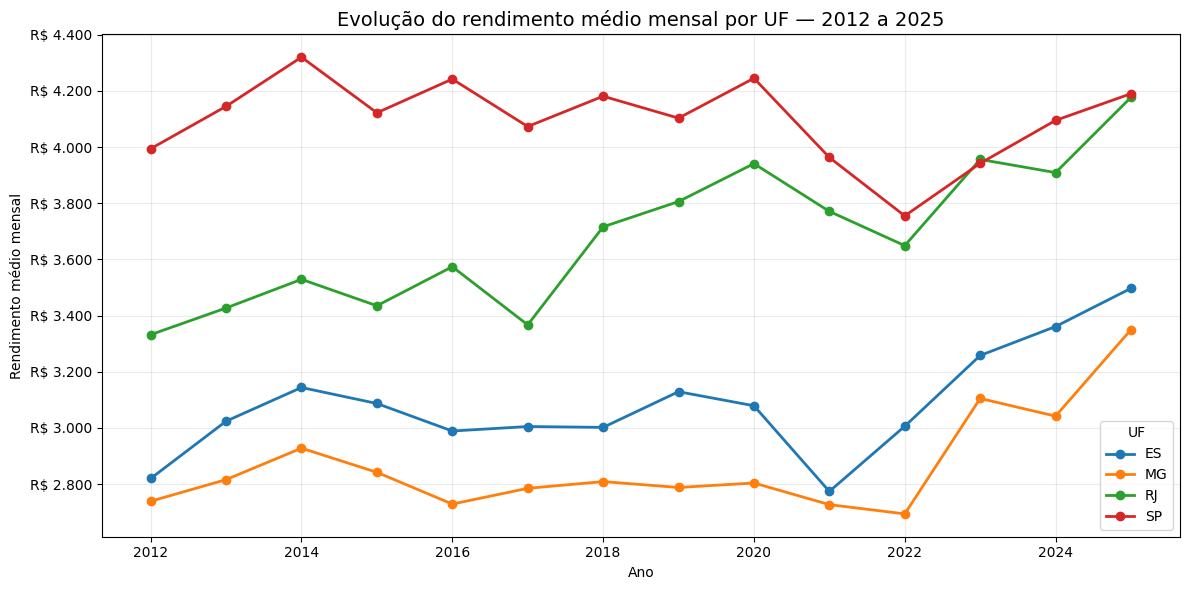

In [0]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Converte somente as colunas necessárias para Pandas.
pdf_contexto_rendimento = (
    df_contexto
    .select(
        "ano",
        "sigla_uf",
        F.col("rendimento_medio_mensal_reais")
        .cast("double")
        .alias("rendimento")
    )
    .orderBy("ano", "sigla_uf")
    .toPandas()
)

# Cria o gráfico da evolução do rendimento.
plt.figure(figsize=(12, 6))

for uf in ["ES", "MG", "RJ", "SP"]:
    dados_uf = pdf_contexto_rendimento[
        pdf_contexto_rendimento["sigla_uf"] == uf
    ]

    plt.plot(
        dados_uf["ano"],
        dados_uf["rendimento"],
        marker="o",
        linewidth=2,
        label=uf
    )

plt.title(
    "Evolução do rendimento médio mensal por UF — 2012 a 2025",
    fontsize=14
)
plt.xlabel("Ano")
plt.ylabel("Rendimento médio mensal")
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(
        lambda valor, posicao: f"R$ {valor:,.0f}"
        .replace(",", ".")
    )
)
plt.grid(alpha=0.25)
plt.legend(title="UF")
plt.tight_layout()
plt.show()

### Interpretação do rendimento médio mensal

A evolução do rendimento médio mensal não ocorreu de forma linear. As quatro Unidades da Federação apresentaram oscilações ao longo do período, com redução mais evidente entre ***2020 e 2022*** e recuperação nos anos seguintes.

São Paulo permaneceu com o maior rendimento durante quase todo o período. Entretanto, a diferença em relação ao Rio de Janeiro diminuiu, e os dois estados chegaram a valores próximos em 2025.

Espírito Santo e Minas Gerais apresentaram rendimentos inferiores aos de São Paulo e Rio de Janeiro durante todo o intervalo analisado. Ainda assim, ambos demonstraram recuperação relevante após 2022.

O gráfico também evidencia a importância de analisar toda a série histórica, pois a comparação apenas entre o primeiro e o último ano ocultaria as oscilações existentes entre esses dois pontos.

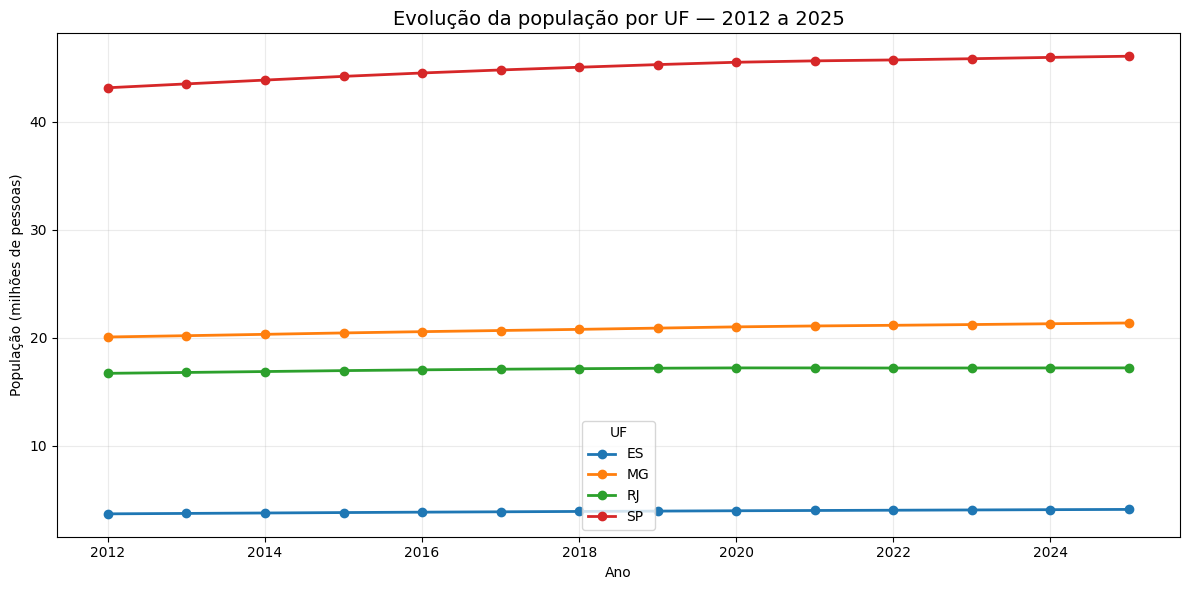

In [0]:
# Converte os dados populacionais necessários para Pandas.
pdf_contexto_populacao = (
    df_contexto
    .select(
        "ano",
        "sigla_uf",
        F.col("populacao_total")
        .cast("double")
        .alias("populacao")
    )
    .orderBy("ano", "sigla_uf")
    .toPandas()
)

# Cria o gráfico da evolução da população.
plt.figure(figsize=(12, 6))

for uf in ["ES", "MG", "RJ", "SP"]:
    dados_uf = pdf_contexto_populacao[
        pdf_contexto_populacao["sigla_uf"] == uf
    ]

    plt.plot(
        dados_uf["ano"],
        dados_uf["populacao"] / 1_000_000,
        marker="o",
        linewidth=2,
        label=uf
    )

plt.title(
    "Evolução da população por UF — 2012 a 2025",
    fontsize=14
)
plt.xlabel("Ano")
plt.ylabel("População (milhões de pessoas)")
plt.grid(alpha=0.25)
plt.legend(title="UF")
plt.tight_layout()
plt.show()

### Interpretação da evolução populacional

São Paulo apresentou a maior população em todos os anos analisados, passando de aproximadamente ***43,16 milhões*** de pessoas em 2012 para ***46,08 milhões*** em 2025. Em termos absolutos, foi também o maior crescimento, com acréscimo aproximado de ***2,92 milhões*** de pessoas.

Minas Gerais manteve a segunda maior população, seguido pelo Rio de Janeiro e pelo Espírito Santo.

Embora o Espírito Santo possua a menor população entre as quatro UFs, apresentou a maior variação proporcional no período, com crescimento de ***11,05%***. O Rio de Janeiro registrou a menor variação proporcional, de ***3,01%***.

As diferenças populacionais devem ser consideradas na análise da previdência aberta, pois valores totais de contribuições, participantes e resgates tendem a ser influenciados pelo tamanho da população de cada estado. Por isso, o projeto também utiliza indicadores médios e proporcionais, evitando comparações baseadas apenas em volumes absolutos.

## 2. Previdência complementar aberta

Esta seção analisa os indicadores da previdência complementar aberta nos estados da Região Sudeste.

Inicialmente, são comparados os produtos PGBL e Previdência Tradicional. Em seguida, a análise é detalhada por Unidade da Federação, considerando contribuições, resgates, participantes e indicadores relacionados ao rendimento médio.

In [0]:
# Resume os principais indicadores da previdência aberta em 2025
# por tipo de produto.
df_resumo_produtos_2025 = (
    df_indicadores_aberta

    .filter(
        F.col("ano") == 2025
    )

    .groupBy(
        "tipo_produto"
    )

    .agg(
        F.sum("contribuicao_anual").alias(
            "contribuicao_total"
        ),

        F.sum("resgate_pago_anual").alias(
            "resgate_total"
        ),

        F.sum("participantes_fim_ano").alias(
            "participantes"
        )
    )

    # Calcula o saldo entre contribuições e resgates.
    .withColumn(
        "contribuicoes_menos_resgates",
        F.round(
            F.col("contribuicao_total")
            - F.col("resgate_total"),
            2
        )
    )

    # Calcula a contribuição média mensal ponderada
    # pela quantidade de participantes.
    .withColumn(
        "contribuicao_media_mensal_participante",
        F.round(
            F.col("contribuicao_total")
            / F.col("participantes")
            / 12,
            2
        )
    )

    .orderBy("tipo_produto")
)

display(df_resumo_produtos_2025)

tipo_produto,contribuicao_total,resgate_total,participantes,contribuicoes_menos_resgates,contribuicao_media_mensal_participante
PGBL,10878025248.11,10637152605.89,3030158,240872642.22,299.16
PREVTRAD,1701817435.89,2465519016.04,4460434,-763701580.15,31.79


#### Conceito de Previdência Tradicional

Na base da SUSEP, a categoria Previdência Tradicional (`PREVTRAD`) reúne planos de previdência complementar aberta diferentes do **PGBL**. Em geral, são modalidades tradicionais ou contratos mais antigos, que podem possuir regras próprias de contribuição, atualização, garantia, resgate e conversão dos recursos em renda.

Diferentemente do **PGBL**, a Previdência Tradicional não deve ser interpretada como um único produto padronizado. Seus dados agregam contratos com características distintas e possivelmente em diferentes fases de maturidade.

Essa característica deve ser considerada na análise dos resultados. A presença de muitos participantes, contribuições médias menores e resgates superiores às contribuições pode refletir uma carteira mais madura, com maior quantidade de contratos em fase de resgate ou recebimento. Entretanto, essa interpretação é uma hipótese analítica e não pode ser confirmada apenas com os dados agregados disponíveis.

### 2.1 Comparação entre os produtos em 2025

Em 2025, o PGBL apresentou aproximadamente ***R$ 10,88 bilhões*** em contribuições e ***R$ 10,64 bilhões*** em resgates nos quatro estados analisados. A diferença entre esses fluxos foi positiva em cerca de ***R$ 240,87 milhões***.

A Previdência Tradicional registrou aproximadamente ***R$ 1,70 bilhão*** em contribuições e ***R$ 2,47 bilhões*** em resgates, resultando em diferença negativa de aproximadamente ***R$ 763,70 milhões***.

Embora a Previdência Tradicional tenha apresentado maior quantidade agregada de participantes ao final do ano, sua contribuição média mensal por participante foi estimada em ***R$ 31,79***. No **PGBL**, esse indicador alcançou ***R$ 299,16***.

Os resultados indicam maior volume de contribuições e maior contribuição média mensal no **PGBL**. Entretanto, a diferença entre contribuições e resgates representa apenas o saldo dos fluxos informados no período. Ela não deve ser interpretada como lucro, rentabilidade do produto ou variação total do patrimônio, pois não inclui rendimentos dos investimentos nem todos os demais movimentos financeiros.

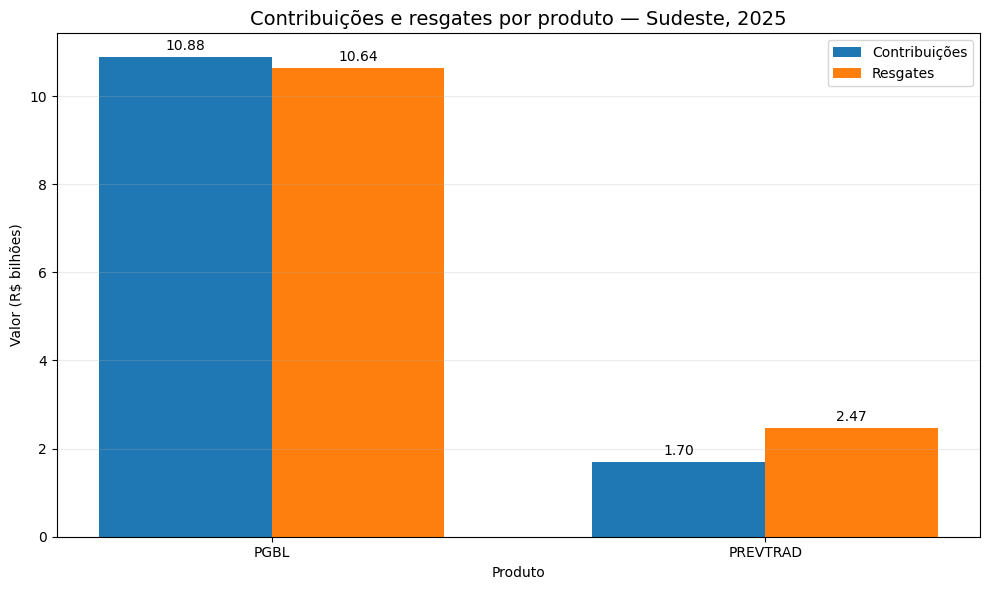

In [0]:
import numpy as np

# Converte o resumo dos produtos para Pandas.
pdf_produtos_2025 = (
    df_resumo_produtos_2025
    .select(
        "tipo_produto",
        F.col("contribuicao_total")
        .cast("double")
        .alias("contribuicao_total"),
        F.col("resgate_total")
        .cast("double")
        .alias("resgate_total")
    )
    .orderBy("tipo_produto")
    .toPandas()
)

# Converte os valores para bilhões de reais.
pdf_produtos_2025["contribuicoes_bilhoes"] = (
    pdf_produtos_2025["contribuicao_total"] / 1_000_000_000
)

pdf_produtos_2025["resgates_bilhoes"] = (
    pdf_produtos_2025["resgate_total"] / 1_000_000_000
)

posicoes = np.arange(len(pdf_produtos_2025))
largura = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

barras_contribuicoes = ax.bar(
    posicoes - largura / 2,
    pdf_produtos_2025["contribuicoes_bilhoes"],
    largura,
    label="Contribuições"
)

barras_resgates = ax.bar(
    posicoes + largura / 2,
    pdf_produtos_2025["resgates_bilhoes"],
    largura,
    label="Resgates"
)

ax.set_title(
    "Contribuições e resgates por produto — Sudeste, 2025",
    fontsize=14
)
ax.set_xlabel("Produto")
ax.set_ylabel("Valor (R$ bilhões)")
ax.set_xticks(posicoes)
ax.set_xticklabels(pdf_produtos_2025["tipo_produto"])
ax.grid(axis="y", alpha=0.25)
ax.legend()

ax.bar_label(
    barras_contribuicoes,
    fmt="%.2f",
    padding=3
)
ax.bar_label(
    barras_resgates,
    fmt="%.2f",
    padding=3
)

plt.tight_layout()
plt.show()

### 2.2 Comparação do PGBL entre as Unidades da Federação

Como o PGBL foi selecionado como produto de referência para as projeções, esta etapa compara a contribuição média mensal por participante e seu percentual em relação ao rendimento médio de cada UF em 2025.

Os indicadores são agregados e devem ser interpretados como referências estaduais, não como valores individuais.

In [0]:
# Seleciona os indicadores de referência do PGBL em 2025.
df_pgbl_uf_2025 = (
    df_indicadores_aberta

    .filter(
        (F.col("ano") == 2025)
        & (F.col("tipo_produto") == "PGBL")
    )

    .select(
        "uf",
        "nome_uf",
        "rendimento_medio_mensal_reais",
        "participantes_fim_ano",
        "contribuicao_anual",
        "contribuicao_media_mensal_participante",
        "percentual_contribuicao_sobre_rendimento"
    )

    .orderBy("uf")
)

display(df_pgbl_uf_2025)

uf,nome_uf,rendimento_medio_mensal_reais,participantes_fim_ano,contribuicao_anual,contribuicao_media_mensal_participante,percentual_contribuicao_sobre_rendimento
ES,Espírito Santo,3497.00,61650,159978238.10,216.25,6.1839
MG,Minas Gerais,3350.00,122415,1049408624.57,714.38,21.3248
RJ,Rio de Janeiro,4177.00,152010,1613426892.26,884.50,21.1755
SP,São Paulo,4190.00,2694083,8055211493.18,249.16,5.9465


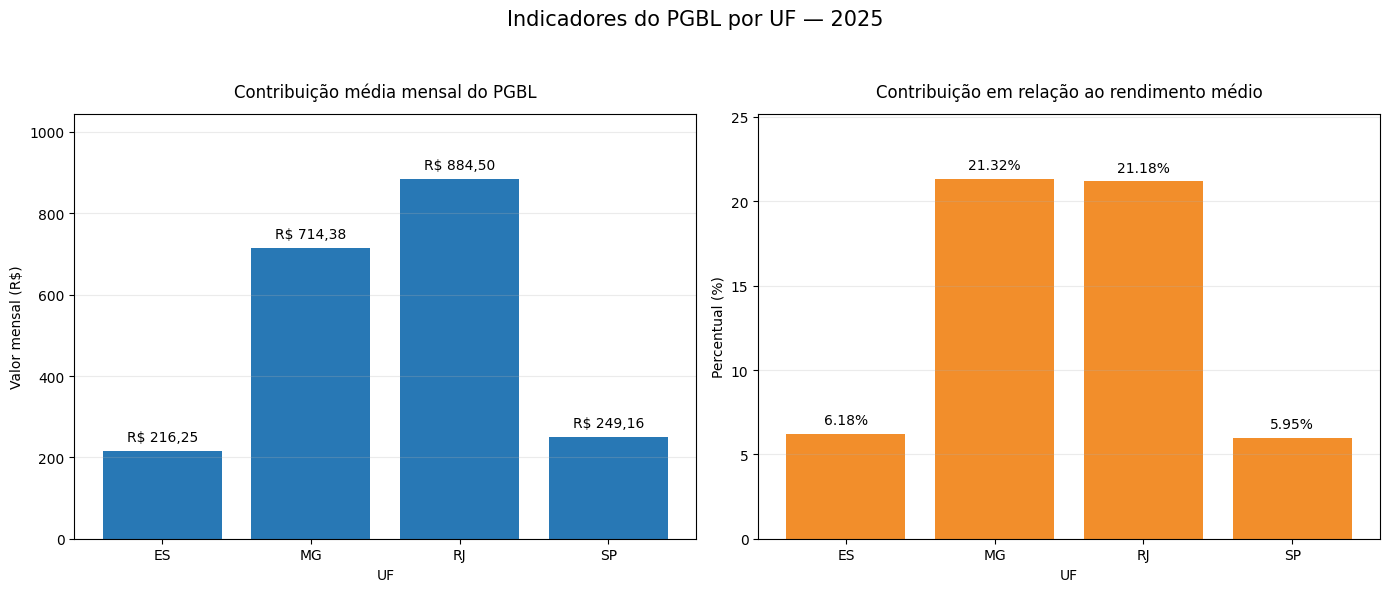

In [0]:
# Converte os indicadores por UF para Pandas.
pdf_pgbl_uf_2025 = (
    df_pgbl_uf_2025
    .select(
        "uf",

        F.col("contribuicao_media_mensal_participante")
        .cast("double")
        .alias("contribuicao_mensal"),

        F.col("percentual_contribuicao_sobre_rendimento")
        .cast("double")
        .alias("percentual_contribuicao")
    )
    .toPandas()
)

fig, eixos = plt.subplots(
    1,
    2,
    figsize=(14, 6)
)

# ---------------------------------------------------------
# Gráfico da contribuição média mensal
# ---------------------------------------------------------

barras_contribuicao = eixos[0].bar(
    pdf_pgbl_uf_2025["uf"],
    pdf_pgbl_uf_2025["contribuicao_mensal"],
    color="#2878B5"
)

eixos[0].set_title(
    "Contribuição média mensal do PGBL",
    pad=12
)

eixos[0].set_xlabel("UF")
eixos[0].set_ylabel("Valor mensal (R$)")
eixos[0].grid(axis="y", alpha=0.25)

# Aumenta o limite superior para os rótulos não ficarem escondidos.
maior_contribuicao = pdf_pgbl_uf_2025["contribuicao_mensal"].max()

eixos[0].set_ylim(
    0,
    maior_contribuicao * 1.18
)

eixos[0].bar_label(
    barras_contribuicao,
    labels=[
        f"R$ {valor:,.2f}"
        .replace(",", "X")
        .replace(".", ",")
        .replace("X", ".")
        for valor in pdf_pgbl_uf_2025["contribuicao_mensal"]
    ],
    padding=5,
    fontsize=10
)

# ---------------------------------------------------------
# Gráfico do percentual sobre o rendimento
# ---------------------------------------------------------

barras_percentual = eixos[1].bar(
    pdf_pgbl_uf_2025["uf"],
    pdf_pgbl_uf_2025["percentual_contribuicao"],
    color="#F28E2B"
)

eixos[1].set_title(
    "Contribuição em relação ao rendimento médio",
    pad=12
)

eixos[1].set_xlabel("UF")
eixos[1].set_ylabel("Percentual (%)")
eixos[1].grid(axis="y", alpha=0.25)

# Aumenta o limite superior para os rótulos não ficarem escondidos.
maior_percentual = pdf_pgbl_uf_2025["percentual_contribuicao"].max()

eixos[1].set_ylim(
    0,
    maior_percentual * 1.18
)

eixos[1].bar_label(
    barras_percentual,
    labels=[
        f"{valor:.2f}%"
        for valor in pdf_pgbl_uf_2025["percentual_contribuicao"]
    ],
    padding=5,
    fontsize=10
)

# ---------------------------------------------------------
# Ajustes gerais
# ---------------------------------------------------------

fig.suptitle(
    "Indicadores do PGBL por UF — 2025",
    fontsize=15,
    y=0.98
)

plt.tight_layout(
    rect=[0, 0, 1, 0.94]
)

plt.show()

### Interpretação dos indicadores do PGBL por UF

Em 2025, o Rio de Janeiro apresentou a maior contribuição média mensal por participante do PGBL, no valor de **R$ 884,50**. Minas Gerais ocupou a segunda posição, com **R$ 714,38**.

Espírito Santo e São Paulo apresentaram valores consideravelmente menores, de **R$ 216,25 e R$ 249,16**, respectivamente.

A diferença permanece evidente quando a contribuição é comparada ao rendimento médio mensal. Em Minas Gerais, a contribuição correspondeu a aproximadamente **21,32%** do rendimento médio, enquanto no Rio de Janeiro representou **21,18%**. No Espírito Santo e em São Paulo, os percentuais foram de aproximadamente **6,18% e 5,95%**.

Essas diferenças são determinantes para as projeções previdenciárias. Mantidas as demais premissas, contribuições maiores em relação à renda produzem maior patrimônio acumulado e maior taxa potencial de reposição.

Os indicadores são médias obtidas pela divisão dos fluxos agregados pela quantidade informada de participantes. Portanto, não significam que todos os participantes de uma UF contribuam mensalmente com esses valores ou percentuais.

In [0]:
# Verifica a estrutura e uma amostra da tabela
# de perfil da previdência complementar fechada.
df_perfil_fechada.printSchema()

display(
    df_perfil_fechada
    .limit(20)
)

root
 |-- data_referencia: date (nullable = true)
 |-- ano_mes: string (nullable = true)
 |-- tipo_populacao: string (nullable = true)
 |-- descricao_populacao: string (nullable = true)
 |-- sexo_padronizado: string (nullable = true)
 |-- faixa_etaria: string (nullable = true)
 |-- ordem_faixa_etaria: integer (nullable = true)
 |-- quantidade_pessoas: long (nullable = true)
 |-- quantidade_informada_liquida: long (nullable = true)
 |-- registros_quantidade_invalida: long (nullable = true)
 |-- entidades_informantes: long (nullable = true)
 |-- abrangencia_geografica: string (nullable = true)
 |-- fonte: string (nullable = true)
 |-- data_processamento: timestamp (nullable = true)
 |-- total_tipo_populacao: long (nullable = true)
 |-- percentual_dentro_tipo: decimal(10,4) (nullable = true)



data_referencia,ano_mes,tipo_populacao,descricao_populacao,sexo_padronizado,faixa_etaria,ordem_faixa_etaria,quantidade_pessoas,quantidade_informada_liquida,registros_quantidade_invalida,entidades_informantes,abrangencia_geografica,fonte,data_processamento,total_tipo_populacao,percentual_dentro_tipo
2025-12-01,202512,APOSENTADOS,Assistidos - Aposentados,FEMININO,ATÉ 24 ANOS,1,114,114,0,227,Brasil,PREVIC - DSI 2025,2026-09-13T02:17:15.871Z,667836,0.0171
2025-12-01,202512,APOSENTADOS,Assistidos - Aposentados,FEMININO,ENTRE 25 E 34 ANOS,2,191,191,0,229,Brasil,PREVIC - DSI 2025,2026-09-13T02:17:15.871Z,667836,0.0286
2025-12-01,202512,APOSENTADOS,Assistidos - Aposentados,FEMININO,ENTRE 35 E 54 ANOS,3,6598,6598,0,238,Brasil,PREVIC - DSI 2025,2026-09-13T02:17:15.871Z,667836,0.9880
2025-12-01,202512,APOSENTADOS,Assistidos - Aposentados,FEMININO,ENTRE 55 E 64 ANOS,4,59856,59856,0,239,Brasil,PREVIC - DSI 2025,2026-09-13T02:17:15.871Z,667836,8.9627
2025-12-01,202512,APOSENTADOS,Assistidos - Aposentados,FEMININO,ENTRE 65 E 74 ANOS,5,97167,97167,0,240,Brasil,PREVIC - DSI 2025,2026-09-13T02:17:15.871Z,667836,14.5495
2025-12-01,202512,APOSENTADOS,Assistidos - Aposentados,FEMININO,ENTRE 75 E 84 ANOS,6,39220,39212,1,240,Brasil,PREVIC - DSI 2025,2026-09-13T02:17:15.871Z,667836,5.8727
2025-12-01,202512,APOSENTADOS,Assistidos - Aposentados,FEMININO,MAIOR QUE 85 ANOS,7,11191,11173,1,237,Brasil,PREVIC - DSI 2025,2026-09-13T02:17:15.871Z,667836,1.6757
2025-12-01,202512,APOSENTADOS,Assistidos - Aposentados,MASCULINO,ATÉ 24 ANOS,1,144,144,0,227,Brasil,PREVIC - DSI 2025,2026-09-13T02:17:15.871Z,667836,0.0216
2025-12-01,202512,APOSENTADOS,Assistidos - Aposentados,MASCULINO,ENTRE 25 E 34 ANOS,2,221,221,0,229,Brasil,PREVIC - DSI 2025,2026-09-13T02:17:15.871Z,667836,0.0331
2025-12-01,202512,APOSENTADOS,Assistidos - Aposentados,MASCULINO,ENTRE 35 E 54 ANOS,3,10962,10962,0,238,Brasil,PREVIC - DSI 2025,2026-09-13T02:17:15.871Z,667836,1.6414


### 2.3 Evolução histórica das contribuições e dos resgates

Esta análise apresenta a evolução dos fluxos anuais de contribuições e resgates do **PGBL** e da Previdência Tradicional entre **2012 e 2025**.

Os valores correspondem à soma dos quatro estados da Região Sudeste. A diferença entre contribuições e resgates representa apenas o saldo desses fluxos e não equivale à rentabilidade ou à variação total do patrimônio.

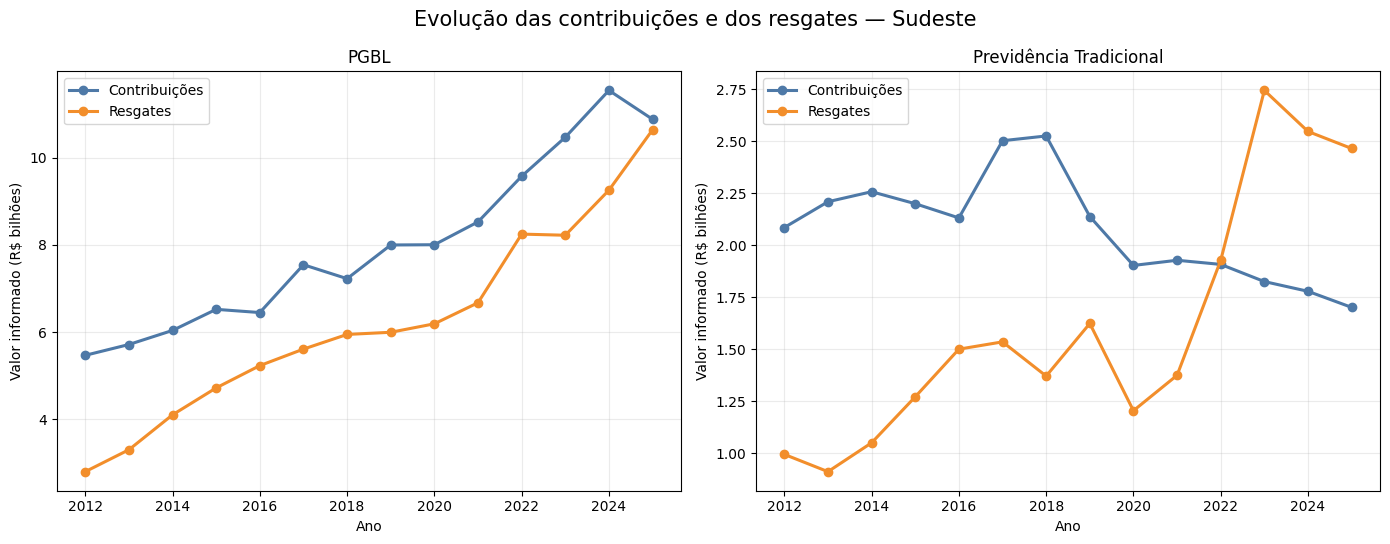

In [0]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt

# Recarrega os indicadores da previdência aberta.
df_indicadores_aberta = spark.table(
    "workspace.gold.indicadores_aberta_contexto_uf_ano"
)

# Agrega os valores das quatro UFs por ano e produto.
df_evolucao_aberta = (
    df_indicadores_aberta

    .groupBy(
        "ano",
        "tipo_produto"
    )

    .agg(
        F.sum("contribuicao_anual").alias(
            "contribuicoes"
        ),

        F.sum("resgate_pago_anual").alias(
            "resgates"
        )
    )

    .orderBy(
        "ano",
        "tipo_produto"
    )
)

# Converte para Pandas.
pdf_evolucao_aberta = (
    df_evolucao_aberta
    .select(
        "ano",
        "tipo_produto",

        (
            F.col("contribuicoes").cast("double")
            / F.lit(1_000_000_000)
        ).alias("contribuicoes_bilhoes"),

        (
            F.col("resgates").cast("double")
            / F.lit(1_000_000_000)
        ).alias("resgates_bilhoes")
    )

    .toPandas()
)

# Cria um painel para cada produto.
fig, eixos = plt.subplots(
    1,
    2,
    figsize=(14, 5.5)
)

produtos = [
    ("PGBL", "PGBL"),
    ("PREVTRAD", "Previdência Tradicional")
]

for eixo, (codigo_produto, nome_produto) in zip(
    eixos,
    produtos
):
    dados_produto = (
        pdf_evolucao_aberta[
            pdf_evolucao_aberta["tipo_produto"]
            == codigo_produto
        ]
        .sort_values("ano")
    )

    eixo.plot(
        dados_produto["ano"],
        dados_produto["contribuicoes_bilhoes"],
        marker="o",
        linewidth=2.2,
        color="#4E79A7",
        label="Contribuições"
    )

    eixo.plot(
        dados_produto["ano"],
        dados_produto["resgates_bilhoes"],
        marker="o",
        linewidth=2.2,
        color="#F28E2B",
        label="Resgates"
    )

    eixo.set_title(
        nome_produto
    )

    eixo.set_xlabel(
        "Ano"
    )

    eixo.set_ylabel(
        "Valor informado (R$ bilhões)"
    )

    eixo.grid(
        alpha=0.25
    )

    eixo.legend()

fig.suptitle(
    "Evolução das contribuições e dos resgates — Sudeste",
    fontsize=15
)

plt.tight_layout()
plt.show()

### Interpretação da evolução histórica

O **PGBL** apresentou crescimento dos fluxos de contribuições e resgates entre **2012 e 2025**. As contribuições passaram de aproximadamente **R$ 5,5 bilhões** em 2012 para **R$ 10,9 bilhões** em 2025, enquanto os resgates aumentaram de aproximadamente **R$ 2,8 bilhões** para **R$ 10,6 bilhões**.

Durante a maior parte do período, as contribuições do **PGBL** permaneceram acima dos resgates. Entretanto, a diferença entre os dois fluxos diminuiu nos anos mais recentes. Em 2025, os valores ficaram próximos, embora as contribuições ainda tenham superado os resgates.

A Previdência Tradicional apresentou comportamento diferente. As contribuições cresceram até aproximadamente 2017 e 2018, mas passaram a diminuir nos anos seguintes, alcançando cerca de **R$ 1,7 bilhão** em 2025.

Os resgates da Previdência Tradicional aumentaram de forma mais intensa a partir de 2021 e superaram as contribuições a partir de 2022. O maior valor da série ocorreu em 2023, quando os resgates alcançaram aproximadamente **R$ 2,75 bilhões**.

Esse comportamento é compatível com a hipótese de uma carteira tradicional mais madura, na qual uma parcela crescente dos contratos pode estar em fase de resgate ou recebimento. Contudo, essa hipótese não pode ser comprovada apenas pelos dados agregados disponíveis.

Os valores apresentados correspondem aos montantes informados em cada ano. Portanto, seu crescimento ao longo do tempo não deve ser interpretado automaticamente como crescimento real, pois a série não foi corrigida para uma mesma moeda-base nesta análise histórica.

A diferença entre contribuições e resgates também não representa rentabilidade ou variação completa do patrimônio, pois não inclui rendimentos dos investimentos nem todos os demais fluxos dos planos.

## 3. Previdência complementar fechada

A previdência complementar fechada é analisada em âmbito nacional, pois a base pública utilizada não apresenta a Unidade da Federação de residência dos participantes.

A análise considera a distribuição da população por situação no plano, sexo e faixa etária. Os registros estão classificados entre participantes ativos, aposentados e beneficiários de pensão.

In [0]:
# Resume a população da previdência fechada
# por situação no plano.
df_resumo_tipo_fechada = (
    df_perfil_fechada

    .groupBy(
        "tipo_populacao",
        "descricao_populacao"
    )

    .agg(
        F.sum("quantidade_pessoas").alias(
            "quantidade_pessoas"
        ),

        F.sum("registros_quantidade_invalida").alias(
            "registros_invalidos"
        ),

        F.max("entidades_informantes").alias(
            "entidades_informantes"
        )
    )

    # Calcula o total geral das três populações.
    .withColumn(
        "total_geral",
        F.sum("quantidade_pessoas").over(
            Window.partitionBy()
        )
    )

    # Calcula a participação de cada tipo no total.
    .withColumn(
        "percentual_total",
        F.round(
            F.col("quantidade_pessoas")
            / F.col("total_geral")
            * 100,
            2
        )
    )

    .orderBy(
        F.desc("quantidade_pessoas")
    )
)

display(df_resumo_tipo_fechada)

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1163: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


tipo_populacao,descricao_populacao,quantidade_pessoas,registros_invalidos,entidades_informantes,total_geral,percentual_total
PARTICIPANTES_ATIVOS,Participantes Ativos,3175915,7,241,4053330,78.35
APOSENTADOS,Assistidos - Aposentados,667836,5,240,4053330,16.48
BENEFICIARIOS_PENSAO,Assistidos - Beneficiários de Pensão,209579,0,239,4053330,5.17


### 3.1 Composição da população por situação no plano

A população válida da previdência complementar fechada totalizou **4.053.330** pessoas em 2025.

Os participantes ativos representam a maior parcela, com **3.175.915** pessoas, correspondentes a **78,35%** do total. Esse grupo se encontra predominantemente na fase de acumulação de recursos.

Os aposentados somam **667.836** pessoas e representam **16,48%** da população. Os beneficiários de pensão totalizam **209.579** pessoas, equivalentes a **5,17%**.

A predominância dos participantes ativos indica que a maior parte da população informada ainda se encontra na fase contributiva. A quantidade de entidades informantes apresentou pequena diferença entre as categorias, variando entre **239 e 241** entidades.

Foram identificados 12 registros com quantidade inválida: sete relacionados aos participantes ativos e cinco aos aposentados. Esses registros foram controlados separadamente e não foram incluídos na quantidade válida de pessoas.

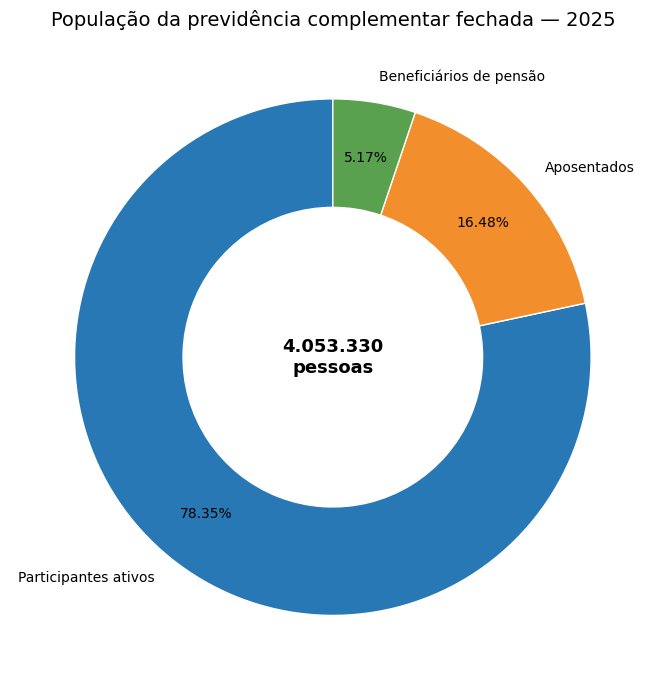

In [0]:
# Converte o resumo para Pandas.
pdf_tipo_fechada = (
    df_resumo_tipo_fechada
    .select(
        "descricao_populacao",
        F.col("quantidade_pessoas")
        .cast("long")
        .alias("quantidade_pessoas")
    )
    .toPandas()
)

# Simplifica os nomes para o gráfico.
nomes_grafico = {
    "Participantes Ativos": "Participantes ativos",
    "Assistidos - Aposentados": "Aposentados",
    "Assistidos - Beneficiários de Pensão":
        "Beneficiários de pensão"
}

pdf_tipo_fechada["categoria"] = (
    pdf_tipo_fechada["descricao_populacao"]
    .replace(nomes_grafico)
)

cores = [
    "#2878B5",
    "#F28E2B",
    "#59A14F"
]

fig, ax = plt.subplots(figsize=(9, 7))

fatias, textos, percentuais = ax.pie(
    pdf_tipo_fechada["quantidade_pessoas"],
    labels=pdf_tipo_fechada["categoria"],
    autopct="%1.2f%%",
    startangle=90,
    colors=cores,
    pctdistance=0.78,
    wedgeprops={
        "width": 0.42,
        "edgecolor": "white"
    }
)

# Mostra o total no centro do gráfico.
total_pessoas = pdf_tipo_fechada[
    "quantidade_pessoas"
].sum()

ax.text(
    0,
    0,
    f"{total_pessoas:,.0f}\npessoas"
    .replace(",", "."),
    ha="center",
    va="center",
    fontsize=13,
    fontweight="bold"
)

ax.set_title(
    "População da previdência complementar fechada — 2025",
    fontsize=14
)

plt.tight_layout()
plt.show()

### 3.2 Distribuição da população por sexo

A distribuição por sexo considera conjuntamente os participantes ativos, aposentados e beneficiários de pensão.

A análise permite identificar a composição geral da população informada pelas entidades fechadas de previdência complementar em 2025.

In [0]:
from pyspark.sql import functions as F

df_perfil_fechada = spark.table(
    "workspace.gold.perfil_previdencia_fechada_2025"
)

# Calcula o total válido de pessoas.
df_total_perfil_fechada = (
    df_perfil_fechada
    .agg(
        F.sum("quantidade_pessoas").alias(
            "total_geral"
        )
    )
)

# Resume a população por sexo.
df_resumo_sexo_fechada = (
    df_perfil_fechada

    .groupBy(
        "sexo_padronizado"
    )

    .agg(
        F.sum("quantidade_pessoas").alias(
            "quantidade_pessoas"
        )
    )

    # Acrescenta o total geral sem utilizar janela.
    .crossJoin(
        df_total_perfil_fechada
    )

    # Calcula a participação de cada sexo.
    .withColumn(
        "percentual_total",
        F.round(
            F.col("quantidade_pessoas")
            / F.col("total_geral")
            * 100,
            2
        )
    )

    .orderBy(
        F.desc("quantidade_pessoas")
    )
)

display(df_resumo_sexo_fechada)

sexo_padronizado,quantidade_pessoas,total_geral,percentual_total
MASCULINO,2475437,4053330,61.07
FEMININO,1577893,4053330,38.93


### Interpretação da distribuição por sexo

Em 2025, a população informada pelas entidades fechadas de previdência complementar apresentou predominância masculina.

Foram identificados **2.475.437** homens, correspondentes a **61,07%**da população válida, e **1.577.893** mulheres, equivalentes a **38,93%**.

Essa diferença descreve a composição agregada da base, mas não permite concluir, isoladamente, que homens possuam maior cobertura previdenciária do que mulheres na população brasileira. Para essa conclusão seriam necessários dados externos comparáveis sobre a população potencialmente elegível e sua participação no mercado de trabalho.


In [0]:
from pyspark.sql.window import Window

# Calcula a distribuição por sexo dentro de cada
# tipo de população da previdência fechada.
df_sexo_tipo_fechada = (
    df_perfil_fechada

    .groupBy(
        "descricao_populacao",
        "sexo_padronizado"
    )

    .agg(
        F.sum("quantidade_pessoas").alias(
            "quantidade_pessoas"
        )
    )

    # Calcula o total de cada tipo de população.
    .withColumn(
        "total_tipo_populacao",
        F.sum("quantidade_pessoas").over(
            Window.partitionBy("descricao_populacao")
        )
    )

    # Calcula o percentual por sexo dentro de cada tipo.
    .withColumn(
        "percentual_no_tipo",
        F.round(
            F.col("quantidade_pessoas")
            / F.col("total_tipo_populacao")
            * 100,
            2
        )
    )

    .orderBy(
        "descricao_populacao",
        "sexo_padronizado"
    )
)

display(df_sexo_tipo_fechada)

descricao_populacao,sexo_padronizado,quantidade_pessoas,total_tipo_populacao,percentual_no_tipo
Assistidos - Aposentados,FEMININO,214337,667836,32.09
Assistidos - Aposentados,MASCULINO,453499,667836,67.91
Assistidos - Beneficiários de Pensão,FEMININO,183066,209579,87.35
Assistidos - Beneficiários de Pensão,MASCULINO,26513,209579,12.65
Participantes Ativos,FEMININO,1180490,3175915,37.17
Participantes Ativos,MASCULINO,1995425,3175915,62.83


### Distribuição por sexo em cada situação no plano

A predominância masculina ocorre entre os participantes ativos e os aposentados. Entre os ativos, os homens representam **62,83%** e as mulheres **37,17%**. Entre os aposentados, a participação masculina aumenta para **67,91%**, enquanto a feminina corresponde a **32,09%**.

A distribuição se inverte entre os beneficiários de pensão. Nesse grupo, as mulheres representam **87,35%** e os homens apenas **12,65%**.

A elevada participação feminina entre os beneficiários de pensão pode estar associada a diferenças históricas de participação no mercado de trabalho, expectativa de vida e composição familiar. Entretanto, essas possíveis explicações não podem ser confirmadas somente com os dados agregados disponíveis.

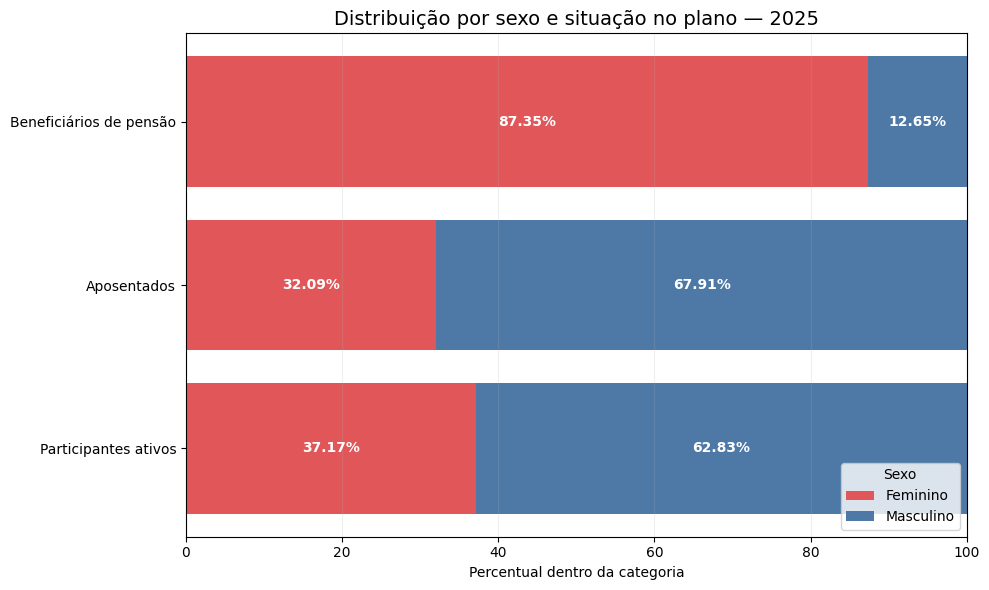

In [0]:
import matplotlib.pyplot as plt

# Converte os percentuais para Pandas.
pdf_sexo_tipo = (
    df_sexo_tipo_fechada
    .select(
        "descricao_populacao",
        "sexo_padronizado",
        F.col("percentual_no_tipo")
        .cast("double")
        .alias("percentual")
    )
    .toPandas()
)

# Organiza os sexos em colunas.
pdf_sexo_tipo_pivot = (
    pdf_sexo_tipo
    .pivot(
        index="descricao_populacao",
        columns="sexo_padronizado",
        values="percentual"
    )
)

# Define nomes mais curtos e a ordem das categorias.
ordem_categorias = [
    "Participantes Ativos",
    "Assistidos - Aposentados",
    "Assistidos - Beneficiários de Pensão"
]

pdf_sexo_tipo_pivot = (
    pdf_sexo_tipo_pivot
    .reindex(ordem_categorias)
)

pdf_sexo_tipo_pivot.index = [
    "Participantes ativos",
    "Aposentados",
    "Beneficiários de pensão"
]

fig, ax = plt.subplots(figsize=(10, 6))

# Barras femininas.
ax.barh(
    pdf_sexo_tipo_pivot.index,
    pdf_sexo_tipo_pivot["FEMININO"],
    label="Feminino",
    color="#E15759"
)

# Barras masculinas empilhadas.
ax.barh(
    pdf_sexo_tipo_pivot.index,
    pdf_sexo_tipo_pivot["MASCULINO"],
    left=pdf_sexo_tipo_pivot["FEMININO"],
    label="Masculino",
    color="#4E79A7"
)

# Adiciona os percentuais dentro das barras.
for indice, categoria in enumerate(
    pdf_sexo_tipo_pivot.index
):
    feminino = pdf_sexo_tipo_pivot.loc[
        categoria,
        "FEMININO"
    ]

    masculino = pdf_sexo_tipo_pivot.loc[
        categoria,
        "MASCULINO"
    ]

    ax.text(
        feminino / 2,
        indice,
        f"{feminino:.2f}%",
        ha="center",
        va="center",
        color="white",
        fontweight="bold"
    )

    ax.text(
        feminino + masculino / 2,
        indice,
        f"{masculino:.2f}%",
        ha="center",
        va="center",
        color="white",
        fontweight="bold"
    )

ax.set_title(
    "Distribuição por sexo e situação no plano — 2025",
    fontsize=14
)
ax.set_xlabel("Percentual dentro da categoria")
ax.set_ylabel("")
ax.set_xlim(0, 100)
ax.legend(title="Sexo", loc="lower right")
ax.grid(axis="x", alpha=0.20)

plt.tight_layout()
plt.show()

### 3.3 Distribuição da população por faixa etária

A distribuição etária permite identificar em quais etapas da vida se concentra a população da previdência complementar fechada.

A análise reúne participantes ativos, aposentados e beneficiários de pensão, mantendo a ordem natural das faixas etárias.

In [0]:
from pyspark.sql import functions as F

# Recarrega a tabela caso a sessão tenha sido reiniciada.
df_perfil_fechada = spark.table(
    "workspace.gold.perfil_previdencia_fechada_2025"
)

# Calcula o total válido da população.
df_total_perfil_fechada = (
    df_perfil_fechada
    .agg(
        F.sum("quantidade_pessoas").alias(
            "total_geral"
        )
    )
)

# Resume a população por faixa etária.
df_resumo_faixa_etaria = (
    df_perfil_fechada

    .groupBy(
        "ordem_faixa_etaria",
        "faixa_etaria"
    )

    .agg(
        F.sum("quantidade_pessoas").alias(
            "quantidade_pessoas"
        )
    )

    .crossJoin(
        df_total_perfil_fechada
    )

    # Calcula a participação de cada faixa no total.
    .withColumn(
        "percentual_total",
        F.round(
            F.col("quantidade_pessoas")
            / F.col("total_geral")
            * 100,
            2
        )
    )

    .orderBy(
        "ordem_faixa_etaria"
    )
)

display(df_resumo_faixa_etaria)

ordem_faixa_etaria,faixa_etaria,quantidade_pessoas,total_geral,percentual_total
1,ATÉ 24 ANOS,294817,4053330,7.27
2,ENTRE 25 E 34 ANOS,585024,4053330,14.43
3,ENTRE 35 E 54 ANOS,1852337,4053330,45.7
4,ENTRE 55 E 64 ANOS,507317,4053330,12.52
5,ENTRE 65 E 74 ANOS,474472,4053330,11.71
6,ENTRE 75 E 84 ANOS,252758,4053330,6.24
7,MAIOR QUE 85 ANOS,86605,4053330,2.14


### Interpretação da distribuição etária

A faixa entre **35 e 54 anos** concentra a maior parcela da população da previdência complementar fechada, com **1.852.337** pessoas, correspondentes a **45,70%** do total válido.

A segunda maior concentração está entre **25 e 34 anos**, com **585.024** pessoas, ou **14,43%**. Em seguida aparece a faixa entre **55 e 64 anos**, com **507.317** pessoas e participação de **12,52%**.

As pessoas com **até 24 anos** representam **7,27%** da população. Esse percentual relativamente reduzido pode indicar menor participação dos mais jovens na previdência complementar fechada ou menor presença desse grupo nos vínculos profissionais associados aos planos.

As faixas **a partir de 65 anos** representam, conjuntamente, **20,09%** da população analisada. A participação diminui progressivamente nas idades mais avançadas, chegando a **2,14%** entre as pessoas **com mais de 85 anos**.

A concentração entre **35 e 54 anos** está relacionada à predominância dos participantes ativos observada anteriormente. Entretanto, a relação entre idade e situação no plano será analisada separadamente para evitar conclusões baseadas somente no total agregado.

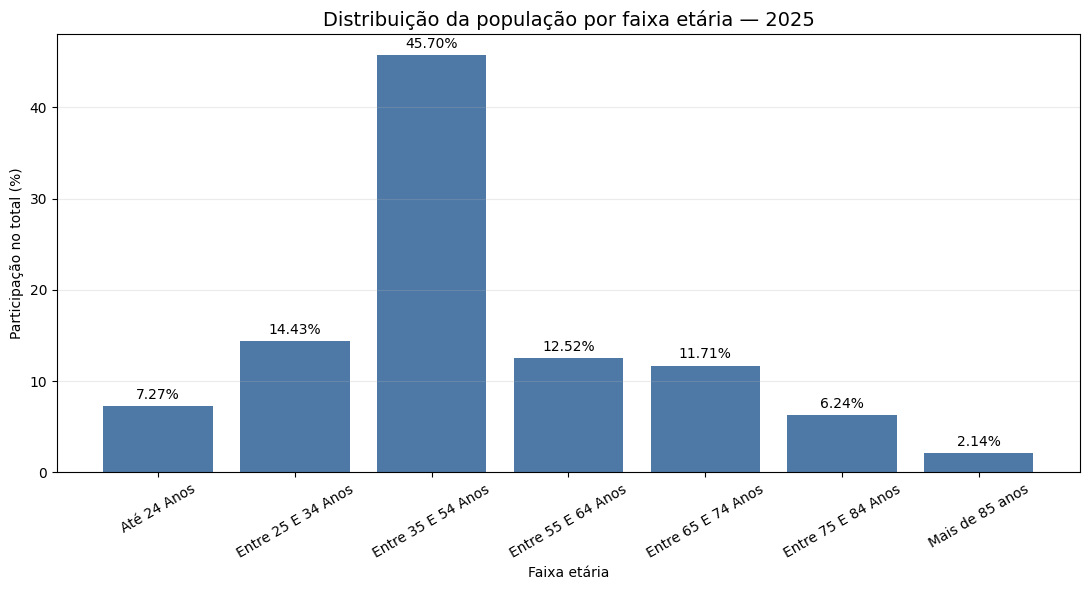

In [0]:
import matplotlib.pyplot as plt

# Converte o resumo etário para Pandas.
pdf_faixa_etaria = (
    df_resumo_faixa_etaria
    .select(
        "ordem_faixa_etaria",
        "faixa_etaria",
        F.col("quantidade_pessoas")
        .cast("long")
        .alias("quantidade_pessoas"),
        F.col("percentual_total")
        .cast("double")
        .alias("percentual_total")
    )
    .orderBy("ordem_faixa_etaria")
    .toPandas()
)

# Padroniza a apresentação dos nomes.
pdf_faixa_etaria["faixa_formatada"] = (
    pdf_faixa_etaria["faixa_etaria"]
    .str.title()
    .str.replace(
        "Maior Que 85 Anos",
        "Mais de 85 anos",
        regex=False
    )
)

fig, ax = plt.subplots(figsize=(11, 6))

barras = ax.bar(
    pdf_faixa_etaria["faixa_formatada"],
    pdf_faixa_etaria["percentual_total"],
    color="#4E79A7"
)

ax.set_title(
    "Distribuição da população por faixa etária — 2025",
    fontsize=14
)
ax.set_xlabel("Faixa etária")
ax.set_ylabel("Participação no total (%)")
ax.grid(axis="y", alpha=0.25)
ax.tick_params(
    axis="x",
    rotation=30
)

ax.bar_label(
    barras,
    labels=[
        f"{valor:.2f}%"
        for valor in pdf_faixa_etaria["percentual_total"]
    ],
    padding=3
)

plt.tight_layout()
plt.show()

### 3.4 Faixa etária por situação no plano

A distribuição etária agregada pode ocultar diferenças entre participantes ativos, aposentados e beneficiários de pensão.

Por isso, esta análise calcula a participação de cada faixa etária dentro de cada situação no plano.

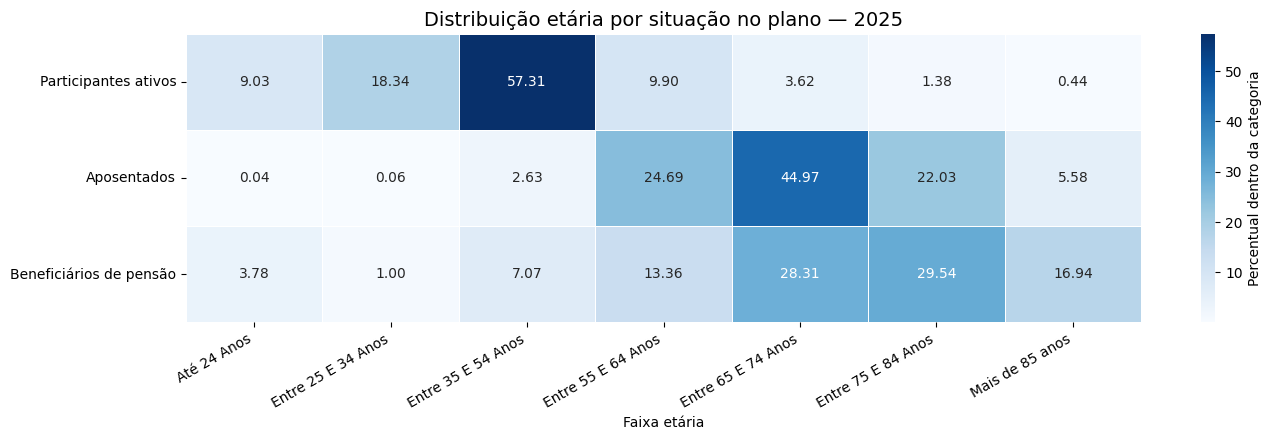

In [0]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window
import matplotlib.pyplot as plt
import seaborn as sns

# Recarrega a tabela caso seja necessário.
df_perfil_fechada = spark.table(
    "workspace.gold.perfil_previdencia_fechada_2025"
)

# Calcula a distribuição etária dentro de cada
# tipo de população.
df_faixa_tipo_fechada = (
    df_perfil_fechada

    .groupBy(
        "descricao_populacao",
        "ordem_faixa_etaria",
        "faixa_etaria"
    )

    .agg(
        F.sum("quantidade_pessoas").alias(
            "quantidade_pessoas"
        )
    )

    .withColumn(
        "total_tipo_populacao",
        F.sum("quantidade_pessoas").over(
            Window.partitionBy("descricao_populacao")
        )
    )

    .withColumn(
        "percentual_no_tipo",
        F.round(
            F.col("quantidade_pessoas")
            / F.col("total_tipo_populacao")
            * 100,
            2
        )
    )

    .orderBy(
        "descricao_populacao",
        "ordem_faixa_etaria"
    )
)

# Converte o resultado para Pandas.
pdf_faixa_tipo = (
    df_faixa_tipo_fechada
    .select(
        "descricao_populacao",
        "ordem_faixa_etaria",
        "faixa_etaria",
        F.col("percentual_no_tipo")
        .cast("double")
        .alias("percentual")
    )
    .toPandas()
)

# Simplifica os nomes das populações.
nomes_populacao = {
    "Participantes Ativos": "Participantes ativos",
    "Assistidos - Aposentados": "Aposentados",
    "Assistidos - Beneficiários de Pensão":
        "Beneficiários de pensão"
}

pdf_faixa_tipo["populacao"] = (
    pdf_faixa_tipo["descricao_populacao"]
    .replace(nomes_populacao)
)

# Padroniza os nomes das faixas etárias.
pdf_faixa_tipo["faixa_formatada"] = (
    pdf_faixa_tipo["faixa_etaria"]
    .str.title()
    .str.replace(
        "Maior Que 85 Anos",
        "Mais de 85 anos",
        regex=False
    )
)

# Obtém a ordem correta das faixas.
ordem_faixas = (
    pdf_faixa_tipo
    .sort_values("ordem_faixa_etaria")
    ["faixa_formatada"]
    .drop_duplicates()
    .tolist()
)

ordem_populacoes = [
    "Participantes ativos",
    "Aposentados",
    "Beneficiários de pensão"
]

# Organiza os percentuais para o mapa de calor.
pdf_matriz_faixa_tipo = (
    pdf_faixa_tipo
    .pivot(
        index="populacao",
        columns="faixa_formatada",
        values="percentual"
    )
    .reindex(
        index=ordem_populacoes,
        columns=ordem_faixas
    )
)

# Cria o mapa de calor.
plt.figure(figsize=(14, 4.5))

sns.heatmap(
    pdf_matriz_faixa_tipo,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={
        "label": "Percentual dentro da categoria"
    }
)

plt.title(
    "Distribuição etária por situação no plano — 2025",
    fontsize=14
)
plt.xlabel("Faixa etária")
plt.ylabel("")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### Interpretação da faixa etária por situação no plano

A distribuição etária apresenta diferenças coerentes com a situação dos participantes nos planos.

Entre os participantes ativos, **57,31%** estão na faixa de **35 a 54 anos**. As pessoas entre **25 e 34 anos** representam **18,34%**, enquanto aquelas **com até 24 anos** correspondem a **9,03%**. A participação diminui consideravelmente após os 65 anos.

Entre os aposentados, a maior concentração ocorre entre **65 e 74 anos**, com **44,97%**. As faixas de **55 a 64 anos** e de **75 a 84 anos** representam, respectivamente, **24,69% e 22,03%**. Apenas **2,73%** dos aposentados **possuem até 54 anos**.

Os beneficiários de pensão apresentam distribuição mais concentrada nas idades avançadas. As pessoas entre **75 e 84 anos** representam **29,54%**, seguidas pela faixa de **65 a 74 anos**, com **28,31%**, e pelas pessoas **com mais de 85 anos**, com **16,94%**.

A existência de beneficiários de pensão nas faixas mais jovens é compatível com a possibilidade de dependentes, como filhos ou outros beneficiários elegíveis. Entretanto, a base agregada não permite identificar o vínculo familiar ou a regra específica que originou cada benefício.

O cruzamento confirma que a concentração geral entre **35 e 54 anos** é explicada principalmente pelos participantes ativos, que representam a maior parte da população analisada.

### Distribuição etária por sexo na previdência complementar fechada — 2025

A pirâmide etária apresenta a distribuição dos participantes, aposentados e beneficiários de pensão da previdência complementar fechada por sexo e faixa etária. O formato permite observar simultaneamente a concentração etária e as diferenças entre homens e mulheres. Por utilizar faixas agregadas, o gráfico caracteriza a composição da base analisada, não representando uma pirâmide demográfica da população brasileira em geral.


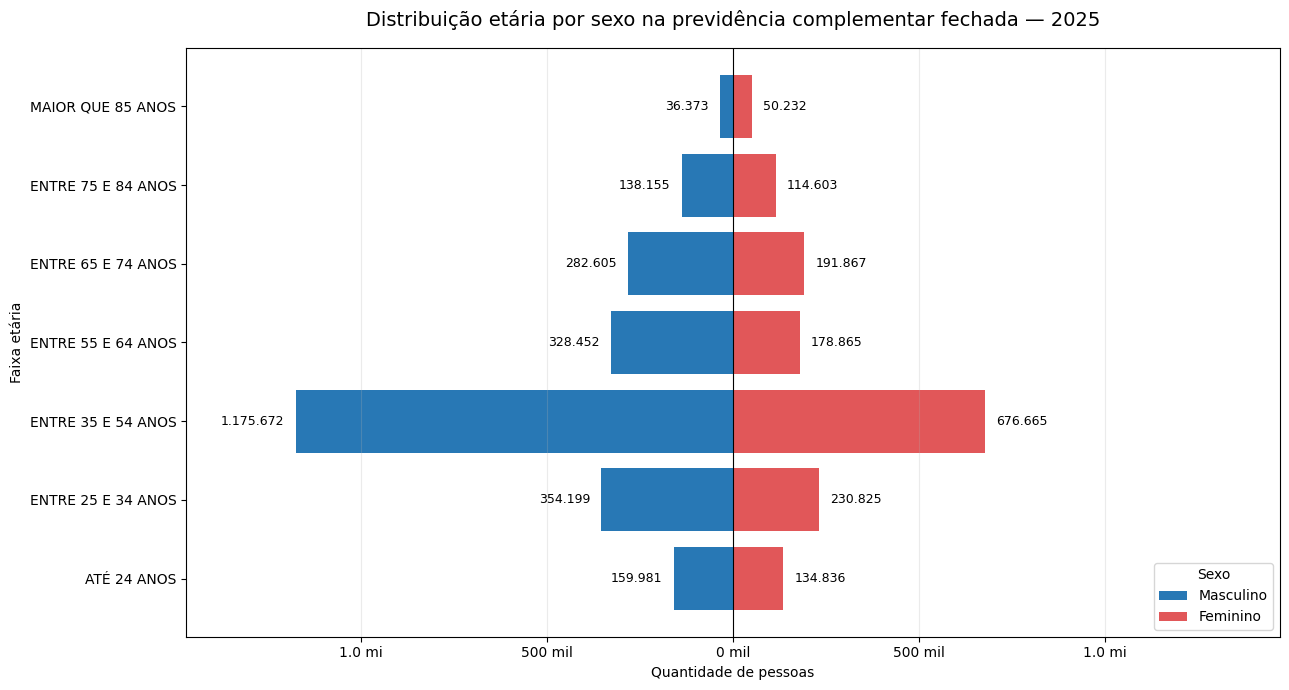

In [0]:
# =========================================================
# Pirâmide etária por sexo — previdência complementar fechada
# =========================================================

from pyspark.sql import functions as F
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Agrupa toda a população da previdência fechada
# por faixa etária e sexo.
df_piramide_etaria = (
    df_perfil_fechada
    .filter(
        F.upper(F.trim(F.col("sexo_padronizado"))).isin(
            "MASCULINO",
            "FEMININO",
            "M",
            "F"
        )
    )
    .withColumn(
        "sexo_piramide",
        F.when(
            F.upper(F.trim(F.col("sexo_padronizado")))
            .isin("MASCULINO", "M"),
            F.lit("Masculino")
        ).otherwise(F.lit("Feminino"))
    )
    .groupBy(
        "ordem_faixa_etaria",
        "faixa_etaria",
        "sexo_piramide"
    )
    .agg(
        F.sum("quantidade_pessoas").alias("quantidade_pessoas")
    )
    .orderBy("ordem_faixa_etaria")
)

# Converte para Pandas.
pdf_piramide_etaria = df_piramide_etaria.toPandas()

# Coloca os sexos em colunas separadas.
pdf_piramide = (
    pdf_piramide_etaria
    .pivot_table(
        index=[
            "ordem_faixa_etaria",
            "faixa_etaria"
        ],
        columns="sexo_piramide",
        values="quantidade_pessoas",
        aggfunc="sum",
        fill_value=0
    )
    .reset_index()
    .sort_values("ordem_faixa_etaria")
)

# Garante que as duas colunas existam.
if "Masculino" not in pdf_piramide.columns:
    pdf_piramide["Masculino"] = 0

if "Feminino" not in pdf_piramide.columns:
    pdf_piramide["Feminino"] = 0

# Homens ficam à esquerda; mulheres, à direita.
pdf_piramide["Masculino_grafico"] = (
    -pdf_piramide["Masculino"]
)

pdf_piramide["Feminino_grafico"] = (
    pdf_piramide["Feminino"]
)

# Define uma escala simétrica.
maior_valor = max(
    pdf_piramide["Masculino"].max(),
    pdf_piramide["Feminino"].max()
)

# Cria o gráfico.
fig, eixo = plt.subplots(
    figsize=(13, 7)
)

barras_masculino = eixo.barh(
    pdf_piramide["faixa_etaria"],
    pdf_piramide["Masculino_grafico"],
    color="#2878B5",
    label="Masculino"
)

barras_feminino = eixo.barh(
    pdf_piramide["faixa_etaria"],
    pdf_piramide["Feminino_grafico"],
    color="#E15759",
    label="Feminino"
)

# Linha central da pirâmide.
eixo.axvline(
    0,
    color="black",
    linewidth=0.8
)

# Mantém a mesma escala nos dois lados.
eixo.set_xlim(
    -maior_valor * 1.25,
    maior_valor * 1.25
)

# Mostra números positivos no eixo horizontal.
eixo.xaxis.set_major_formatter(
    FuncFormatter(
        lambda valor, posicao: (
            f"{abs(valor) / 1_000_000:.1f} mi"
            if abs(valor) >= 1_000_000
            else f"{abs(valor) / 1_000:.0f} mil"
        )
    )
)

# Espaço utilizado para afastar os rótulos das barras.
deslocamento = maior_valor * 0.025

# Rótulos masculinos.
for barra, valor in zip(
    barras_masculino,
    pdf_piramide["Masculino"]
):
    eixo.text(
        barra.get_width() - deslocamento,
        barra.get_y() + barra.get_height() / 2,
        f"{int(valor):,}".replace(",", "."),
        va="center",
        ha="right",
        fontsize=9
    )

# Rótulos femininos.
for barra, valor in zip(
    barras_feminino,
    pdf_piramide["Feminino"]
):
    eixo.text(
        barra.get_width() + deslocamento,
        barra.get_y() + barra.get_height() / 2,
        f"{int(valor):,}".replace(",", "."),
        va="center",
        ha="left",
        fontsize=9
    )

eixo.set_title(
    "Distribuição etária por sexo na previdência complementar fechada — 2025",
    fontsize=14,
    pad=16
)

eixo.set_xlabel("Quantidade de pessoas")
eixo.set_ylabel("Faixa etária")

eixo.legend(
    title="Sexo",
    loc="lower right"
)

eixo.grid(
    axis="x",
    alpha=0.25
)

plt.tight_layout()
plt.show()

### 3.5 Movimentação dos planos e entidades

Esta análise examina as quantidades iniciais, entradas, saídas e quantidades finais registradas por plano e entidade da previdência complementar fechada em 2025.

Também são considerados os controles de qualidade relacionados à cobertura, mudança de entidade e diferenças de conciliação.

In [0]:
# Recarrega a tabela de movimentação diretamente da Gold.
df_movimentacao_fechada = spark.table(
    "workspace.gold.movimentacao_plano_entidade_fechada_2025"
)

# Confere a estrutura e uma amostra dos registros.
df_movimentacao_fechada.printSchema()

display(
    df_movimentacao_fechada
    .limit(15)
)

root
 |-- cnpb_plano: string (nullable = true)
 |-- ano: integer (nullable = true)
 |-- codigo_entidade: integer (nullable = true)
 |-- sigla_entidade: string (nullable = true)
 |-- codigo_plano: integer (nullable = true)
 |-- tipo_populacao: string (nullable = true)
 |-- codigo_conta: integer (nullable = true)
 |-- primeiro_mes_disponivel: integer (nullable = true)
 |-- ultimo_mes_disponivel: integer (nullable = true)
 |-- data_posicao_inicial: date (nullable = true)
 |-- data_posicao_final: date (nullable = true)
 |-- periodos_com_dados: long (nullable = true)
 |-- quantidade_inicial_ano: long (nullable = true)
 |-- entradas_ano: long (nullable = true)
 |-- saidas_ano: long (nullable = true)
 |-- quantidade_final_ano: long (nullable = true)
 |-- registros_invalidos: long (nullable = true)
 |-- registros_origem: long (nullable = true)
 |-- saldo_movimentacao_ano: long (nullable = true)
 |-- variacao_estoque_ano: long (nullable = true)
 |-- diferenca_reconciliacao: long (nullable = tru

cnpb_plano,ano,codigo_entidade,sigla_entidade,codigo_plano,tipo_populacao,codigo_conta,primeiro_mes_disponivel,ultimo_mes_disponivel,data_posicao_inicial,data_posicao_final,periodos_com_dados,quantidade_inicial_ano,entradas_ano,saidas_ano,quantidade_final_ano,registros_invalidos,registros_origem,saldo_movimentacao_ano,variacao_estoque_ano,diferenca_reconciliacao,abrangencia_geografica,fonte,data_processamento,quantidade_entidades_no_ano,entidades_identificadas,flag_mudanca_entidade,flag_cobertura_incompleta,flag_diferenca_reconciliacao,flag_apto_analise_movimentacao
1980000883,2025,14,AGROS,13,APOSENTADOS,11000,1,12,2025-01-01,2025-12-01,12,70,0,6,64,0,12,-6,-6,0,Brasil,PREVIC - EPB 2025,2026-09-13T03:14:48.583Z,null,null,false,false,false,true
1992000174,2025,14,AGROS,14,APOSENTADOS,11000,1,12,2025-01-01,2025-12-01,12,0,0,0,0,0,12,0,0,0,Brasil,PREVIC - EPB 2025,2026-09-13T03:14:48.583Z,null,null,false,false,false,true
2008001083,2025,14,AGROS,1157,APOSENTADOS,11000,1,12,2025-01-01,2025-12-01,12,29,3,0,32,0,12,3,3,0,Brasil,PREVIC - EPB 2025,2026-09-13T03:14:48.583Z,null,null,false,false,false,true
2023001692,2025,14,AGROS,8687,APOSENTADOS,11000,1,12,2025-01-01,2025-12-01,12,2773,40,63,2750,0,12,-23,-23,0,Brasil,PREVIC - EPB 2025,2026-09-13T03:14:48.583Z,null,null,false,false,false,true
1988003156,2025,31,ALCOA PREVI,15,APOSENTADOS,11000,1,12,2025-01-01,2025-12-01,12,178,10,4,184,0,12,6,6,0,Brasil,PREVIC - EPB 2025,2026-09-13T03:14:48.583Z,null,null,false,false,false,true
1999002474,2025,45,ALPHA,16,APOSENTADOS,11000,1,12,2025-01-01,2025-12-01,12,197,18,5,210,0,12,13,13,0,Brasil,PREVIC - EPB 2025,2026-09-13T03:14:48.583Z,null,null,false,false,false,true
1982000783,2025,59,INFRAPREV,18,APOSENTADOS,11000,1,12,2025-01-01,2025-12-01,12,85,0,5,80,0,12,-5,-5,0,Brasil,PREVIC - EPB 2025,2026-09-13T03:14:48.583Z,null,null,false,false,false,true
1982001811,2025,59,INFRAPREV,19,APOSENTADOS,11000,1,12,2025-01-01,2025-12-01,12,9,0,1,8,0,12,-1,-1,0,Brasil,PREVIC - EPB 2025,2026-09-13T03:14:48.583Z,null,null,false,false,false,true
2000008119,2025,59,INFRAPREV,17,APOSENTADOS,11000,1,12,2025-01-01,2025-12-01,12,3809,421,276,3954,0,12,145,145,0,Brasil,PREVIC - EPB 2025,2026-09-13T03:14:48.583Z,null,null,false,false,false,true
2012000819,2025,59,INFRAPREV,3704,APOSENTADOS,11000,1,12,2025-01-01,2025-12-01,12,194,138,1,331,0,12,137,137,0,Brasil,PREVIC - EPB 2025,2026-09-13T03:14:48.583Z,null,null,false,false,false,true


In [0]:
# Resume a movimentação por tipo de população.
df_resumo_movimentacao_fechada = (
    df_movimentacao_fechada

    .groupBy(
        "tipo_populacao"
    )

    .agg(
        F.count("*").alias(
            "registros"
        ),

        F.countDistinct("cnpb_plano").alias(
            "planos_distintos"
        ),

        F.sum("quantidade_inicial_ano").alias(
            "quantidade_inicial"
        ),

        F.sum("entradas_ano").alias(
            "entradas"
        ),

        F.sum("saidas_ano").alias(
            "saidas"
        ),

        F.sum("quantidade_final_ano").alias(
            "quantidade_final"
        ),

        F.sum(
            F.when(
                F.col("flag_mudanca_entidade"),
                1
            ).otherwise(0)
        ).alias("linhas_com_mudanca_entidade"),

        F.sum(
            F.when(
                F.col("flag_cobertura_incompleta"),
                1
            ).otherwise(0)
        ).alias("linhas_com_cobertura_incompleta"),

        F.sum(
            F.when(
                F.col("flag_diferenca_reconciliacao"),
                1
            ).otherwise(0)
        ).alias("linhas_com_diferenca_reconciliacao"),

        F.sum(
            F.when(
                F.col("flag_apto_analise_movimentacao"),
                1
            ).otherwise(0)
        ).alias("registros_aptos")
    )

    # Calcula a variação líquida informada.
    .withColumn(
        "variacao_liquida",
        F.col("entradas") - F.col("saidas")
    )

    # Calcula a variação percentual sobre a quantidade inicial.
    .withColumn(
        "variacao_percentual",
        F.round(
            F.when(
                F.col("quantidade_inicial") > 0,
                (
                    F.col("quantidade_final")
                    / F.col("quantidade_inicial")
                    - 1
                ) * 100
            ),
            2
        )
    )

    .orderBy("tipo_populacao")
)

display(df_resumo_movimentacao_fechada)

tipo_populacao,registros,planos_distintos,quantidade_inicial,entradas,saidas,quantidade_final,linhas_com_mudanca_entidade,linhas_com_cobertura_incompleta,linhas_com_diferenca_reconciliacao,registros_aptos,variacao_liquida,variacao_percentual
APOSENTADOS,1084,1074,688500,52768,54192,687033,20,41,10,1024,-1424,-0.21
BENEFICIARIOS_PENSAO,1085,1075,208181,22426,19039,211575,20,46,5,1025,3387,1.63
PARTICIPANTES_ATIVOS,1097,1087,3247876,502391,415783,3334556,20,34,13,1043,86608,2.67


### 3.6 Interpretação da movimentação em 2025

Os participantes ativos apresentaram a maior movimentação no período. Foram registradas **502.391** entradas e **415.783** saídas, resultando em variação líquida informada de **86.608** pessoas. A quantidade final foi **2,67%** superior à quantidade inicial.

Entre os beneficiários de pensão, foram observadas **22.426**entradas e **19.039** saídas. A quantidade final apresentou crescimento de **1,63%** em relação à quantidade inicial.

Os aposentados registraram **52.768** entradas e **54.192** saídas, com variação líquida negativa de **1.424** pessoas. A quantidade final foi **0,21%** inferior à inicial.

As diferenças entre a variação calculada por entradas e saídas e a alteração entre as quantidades inicial e final estão relacionadas aos registros com diferença de conciliação. Por esse motivo, o pipeline preservou flags de qualidade e identificou separadamente os registros aptos para análise.

Foram identificadas 121 linhas com cobertura temporal incompleta e 28 linhas com diferença de conciliação. Também foram encontradas 60 linhas associadas a mudanças de entidade, correspondentes a ocorrências repetidas nas diferentes categorias populacionais e entidades envolvidas. Esses valores representam linhas da tabela, e não necessariamente a quantidade distinta de planos afetados.

Dos 3.266 registros da tabela, 3.092 foram classificados como aptos para a análise de movimentação.

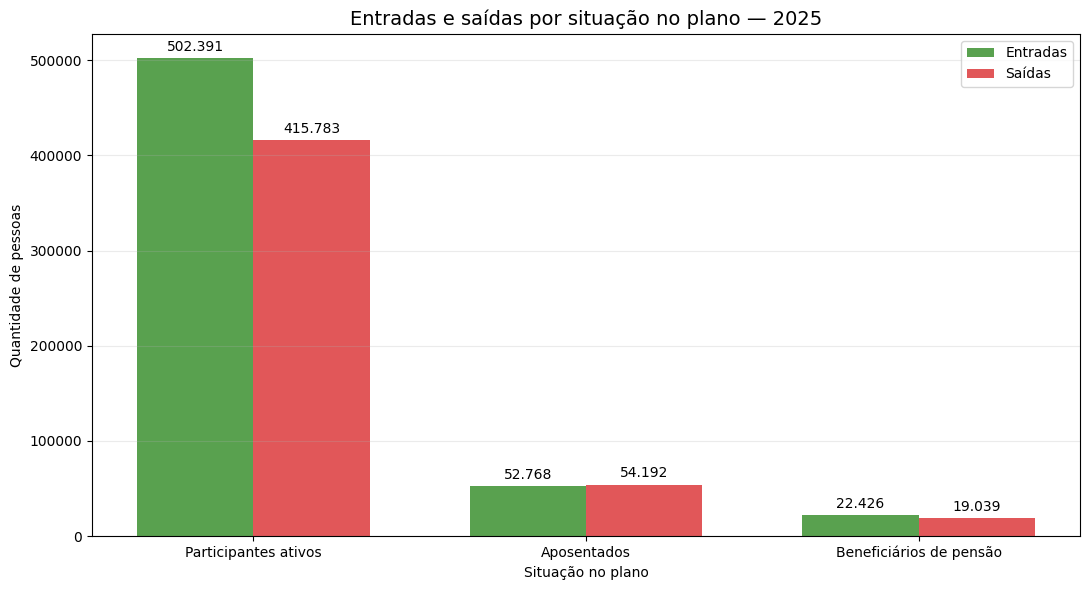

In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Converte o resumo para Pandas.
pdf_movimentacao_fechada = (
    df_resumo_movimentacao_fechada
    .select(
        "tipo_populacao",
        F.col("entradas")
        .cast("double")
        .alias("entradas"),
        F.col("saidas")
        .cast("double")
        .alias("saidas"),
        F.col("variacao_percentual")
        .cast("double")
        .alias("variacao_percentual")
    )
    .toPandas()
)

# Define nomes e ordem mais claros.
nomes_movimentacao = {
    "PARTICIPANTES_ATIVOS": "Participantes ativos",
    "APOSENTADOS": "Aposentados",
    "BENEFICIARIOS_PENSAO": "Beneficiários de pensão"
}

pdf_movimentacao_fechada["categoria"] = (
    pdf_movimentacao_fechada["tipo_populacao"]
    .replace(nomes_movimentacao)
)

ordem_movimentacao = [
    "Participantes ativos",
    "Aposentados",
    "Beneficiários de pensão"
]

pdf_movimentacao_fechada["categoria"] = (
    pd.Categorical(
        pdf_movimentacao_fechada["categoria"],
        categories=ordem_movimentacao,
        ordered=True
    )
)

pdf_movimentacao_fechada = (
    pdf_movimentacao_fechada
    .sort_values("categoria")
)

posicoes = np.arange(
    len(pdf_movimentacao_fechada)
)
largura = 0.35

fig, ax = plt.subplots(figsize=(11, 6))

barras_entradas = ax.bar(
    posicoes - largura / 2,
    pdf_movimentacao_fechada["entradas"],
    largura,
    label="Entradas",
    color="#59A14F"
)

barras_saidas = ax.bar(
    posicoes + largura / 2,
    pdf_movimentacao_fechada["saidas"],
    largura,
    label="Saídas",
    color="#E15759"
)

ax.set_title(
    "Entradas e saídas por situação no plano — 2025",
    fontsize=14
)
ax.set_xlabel("Situação no plano")
ax.set_ylabel("Quantidade de pessoas")
ax.set_xticks(posicoes)
ax.set_xticklabels(
    pdf_movimentacao_fechada["categoria"]
)
ax.grid(axis="y", alpha=0.25)
ax.legend()

ax.bar_label(
    barras_entradas,
    labels=[
        f"{valor:,.0f}".replace(",", ".")
        for valor in pdf_movimentacao_fechada["entradas"]
    ],
    padding=3
)

ax.bar_label(
    barras_saidas,
    labels=[
        f"{valor:,.0f}".replace(",", ".")
        for valor in pdf_movimentacao_fechada["saidas"]
    ],
    padding=3
)

plt.tight_layout()
plt.show()

## 4. Cenários de reposição de renda

Esta seção analisa as projeções construídas para o **PGBL** com base nas contribuições médias observadas em 2025 nos estados do **Espírito Santo, Minas Gerais, Rio de Janeiro e São Paulo**.

Foram considerados três horizontes de acumulação:

- **10 anos;**
- **20 anos;**
- **30 anos.**

Para cada horizonte foram simulados três cenários de rentabilidade real anual:

- **conservador: 2%;**
- **base: 4%;**
- **otimista: 6%.**

O patrimônio projetado foi convertido em renda mensal **durante 20 anos**, considerando **rentabilidade real de 2% ao ano** na fase de recebimento. Os resultados são expressos em reais constantes de 2025.

In [0]:
from pyspark.sql import functions as F

# Recarrega os cenários detalhados diretamente da Gold.
df_cenarios = spark.table(
    "workspace.gold.cenarios_reposicao_renda_2025"
)

# Seleciona os principais resultados das projeções.
df_resultados_cenarios = (
    df_cenarios

    .select(
        "uf",
        "nome_uf",
        "horizonte_anos",
        "cenario",
        "contribuicao_media_mensal_participante",
        "taxa_retorno_real_acumulacao_anual",
        "patrimonio_acumulado",
        "renda_mensal_projetada",
        "taxa_reposicao_renda_percentual"
    )

    .orderBy(
        "uf",
        "horizonte_anos",
        "cenario"
    )
)

display(df_resultados_cenarios)

uf,nome_uf,horizonte_anos,cenario,contribuicao_media_mensal_participante,taxa_retorno_real_acumulacao_anual,patrimonio_acumulado,renda_mensal_projetada,taxa_reposicao_renda_percentual
ES,Espírito Santo,10,BASE,216.25,0.04,31722.99,160.21,4.5814
ES,Espírito Santo,10,CONSERVADOR,216.25,0.02,28674.06,144.81,4.1410
ES,Espírito Santo,10,OTIMISTA,216.25,0.06,35134.88,177.44,5.0741
ES,Espírito Santo,20,BASE,216.25,0.04,78680.77,397.36,11.3629
ES,Espírito Santo,20,CONSERVADOR,216.25,0.02,63627.58,321.34,9.1890
ES,Espírito Santo,20,OTIMISTA,216.25,0.06,98056.10,495.21,14.1610
ES,Espírito Santo,30,BASE,216.25,0.04,148189.76,748.40,21.4012
ES,Espírito Santo,30,CONSERVADOR,216.25,0.02,106235.73,536.52,15.3423
ES,Espírito Santo,30,OTIMISTA,216.25,0.06,210738.43,1064.28,30.4341
MG,Minas Gerais,10,BASE,714.38,0.04,104796.63,529.25,15.7985


### 4.1 Taxa de reposição por UF, horizonte e cenário

A taxa de reposição representa o percentual do rendimento mensal de referência que poderia ser substituído pela renda complementar projetada.

O gráfico compara os três cenários de rentabilidade nos horizontes de **10, 20 e 30 anos**, mantendo constante a contribuição mensal de referência de cada UF.

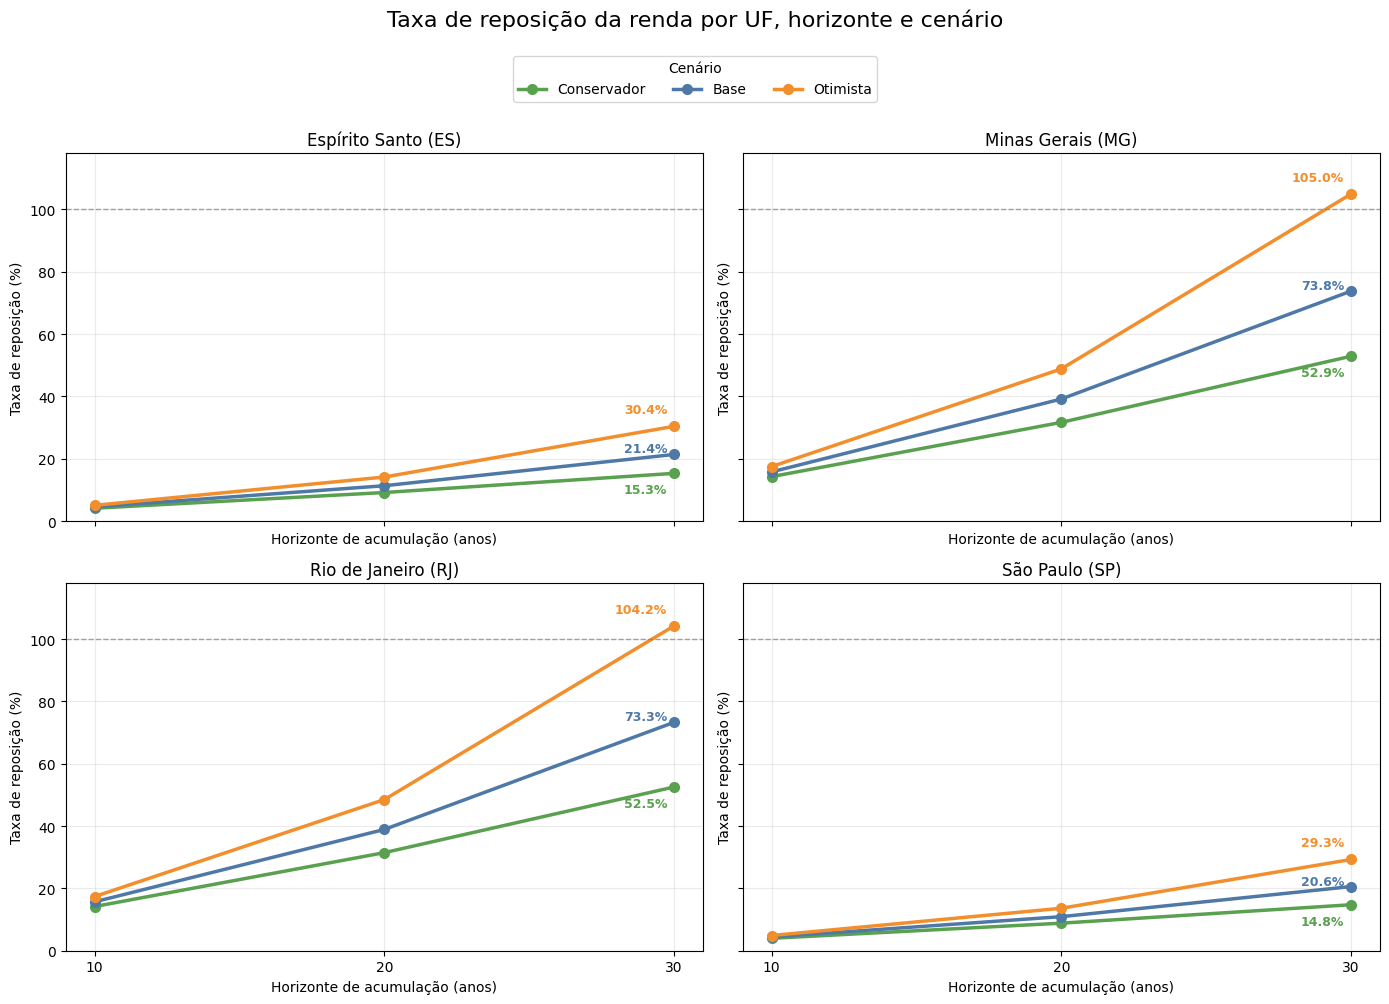

In [0]:
from pyspark.sql import functions as F
import pandas as pd
import matplotlib.pyplot as plt

# Recarrega os cenários da camada Gold.
df_cenarios = spark.table(
    "workspace.gold.cenarios_reposicao_renda_2025"
)

# Prepara os dados.
pdf_taxa_reposicao = (
    df_cenarios
    .select(
        "uf",
        "nome_uf",
        "horizonte_anos",
        "cenario",
        F.col("taxa_reposicao_renda_percentual")
        .cast("double")
        .alias("taxa_reposicao")
    )
    .toPandas()
)

ordem_cenarios = [
    "CONSERVADOR",
    "BASE",
    "OTIMISTA"
]

cores_cenarios = {
    "CONSERVADOR": "#59A14F",
    "BASE": "#4E79A7",
    "OTIMISTA": "#F28E2B"
}

nomes_cenarios = {
    "CONSERVADOR": "Conservador",
    "BASE": "Base",
    "OTIMISTA": "Otimista"
}

# Deslocamento vertical apenas para os rótulos de 30 anos.
deslocamento_final = {
    "CONSERVADOR": -12,
    "BASE": 4,
    "OTIMISTA": 12
}

ordem_ufs = [
    "ES",
    "MG",
    "RJ",
    "SP"
]

fig, eixos = plt.subplots(
    2,
    2,
    figsize=(14, 10),
    sharex=True,
    sharey=True
)

eixos = eixos.flatten()

for eixo, uf in zip(eixos, ordem_ufs):

    dados_uf = pdf_taxa_reposicao[
        pdf_taxa_reposicao["uf"] == uf
    ]

    nome_uf = dados_uf["nome_uf"].iloc[0]

    for cenario in ordem_cenarios:

        dados_cenario = (
            dados_uf[
                dados_uf["cenario"] == cenario
            ]
            .sort_values("horizonte_anos")
        )

        eixo.plot(
            dados_cenario["horizonte_anos"],
            dados_cenario["taxa_reposicao"],
            marker="o",
            linewidth=2.5,
            markersize=7,
            color=cores_cenarios[cenario],
            label=nomes_cenarios[cenario]
        )

        # Exibe somente o valor referente a 30 anos.
        ponto_final = (
            dados_cenario[
                dados_cenario["horizonte_anos"] == 30
            ]
            .iloc[0]
        )

        eixo.annotate(
            f"{ponto_final['taxa_reposicao']:.1f}%",
            (
                ponto_final["horizonte_anos"],
                ponto_final["taxa_reposicao"]
            ),
            textcoords="offset points",
            xytext=(
                -5,
                deslocamento_final[cenario]
            ),
            ha="right",
            va="center",
            fontsize=9,
            fontweight="bold",
            color=cores_cenarios[cenario]
        )

    # Referência de reposição integral.
    eixo.axhline(
        y=100,
        color="gray",
        linestyle="--",
        linewidth=1,
        alpha=0.7
    )

    eixo.set_ylim(
        0,
        118
    )

    eixo.set_xlim(
        9,
        31
    )

    eixo.set_title(
        f"{nome_uf} ({uf})"
    )

    eixo.set_xticks(
        [10, 20, 30]
    )

    eixo.set_xlabel(
        "Horizonte de acumulação (anos)"
    )

    eixo.set_ylabel(
        "Taxa de reposição (%)"
    )

    eixo.grid(
        alpha=0.25
    )

# Legenda única.
handles, labels = (
    eixos[0].get_legend_handles_labels()
)

fig.legend(
    handles,
    labels,
    title="Cenário",
    loc="upper center",
    ncol=3,
    bbox_to_anchor=(0.5, 0.96)
)

fig.suptitle(
    "Taxa de reposição da renda por UF, horizonte e cenário",
    fontsize=16,
    y=1.00
)

plt.tight_layout(
    rect=[0, 0, 1, 0.93]
)

plt.show()

### 4.2 Efeito do prazo e da rentabilidade sobre a acumulação

Como cada UF possui uma contribuição mensal diferente, os patrimônios projetados também apresentam escalas distintas.

Para isolar o efeito do prazo e da rentabilidade, esta análise calcula quanto o patrimônio projetado supera o total nominalmente contribuído, considerando valores constantes de 2025.

In [0]:
# Calcula o efeito proporcional da rentabilidade
# em cada horizonte e cenário.
df_efeito_acumulacao = (
    df_cenarios

    .withColumn(
        "percentual_acrescimo_rentabilidade",
        F.round(
            F.col("rendimento_real_acumulado")
            / F.col("total_contribuido")
            * 100,
            2
        )
    )

    .withColumn(
        "multiplicador_patrimonio",
        F.round(
            F.col("patrimonio_acumulado")
            / F.col("total_contribuido"),
            2
        )
    )

    # O efeito proporcional é igual entre as UFs,
    # pois todas usam a mesma taxa e o mesmo horizonte.
    .groupBy(
        "horizonte_anos",
        "cenario",
        "taxa_retorno_real_acumulacao_anual"
    )

    .agg(
        F.round(
            F.avg("percentual_acrescimo_rentabilidade"),
            2
        ).alias("acrescimo_sobre_contribuicoes_percentual"),

        F.round(
            F.avg("multiplicador_patrimonio"),
            2
        ).alias("multiplicador_medio_patrimonio")
    )

    .orderBy(
        "horizonte_anos",
        "taxa_retorno_real_acumulacao_anual"
    )
)

display(df_efeito_acumulacao)

horizonte_anos,cenario,taxa_retorno_real_acumulacao_anual,acrescimo_sobre_contribuicoes_percentual,multiplicador_medio_patrimonio
10,CONSERVADOR,0.02,10.50,1.10
10,BASE,0.04,22.25,1.22
10,OTIMISTA,0.06,35.39,1.35
20,CONSERVADOR,0.02,22.60,1.23
20,BASE,0.04,51.60,1.52
20,OTIMISTA,0.06,88.93,1.89
30,CONSERVADOR,0.02,36.46,1.36
30,BASE,0.04,90.35,1.90
30,OTIMISTA,0.06,170.70,2.71


### Interpretação do efeito da acumulação

O efeito da rentabilidade aumenta de forma não linear conforme o prazo de acumulação se torna maior.

Em **10 anos**, o patrimônio projetado supera o total contribuído em **10,50% no cenário conservador**, **22,25% no cenário base** e **35,39% no cenário otimista**.

Em **20 anos**, os acréscimos aumentam para **22,60%, 51,60% e 88,93%**, respectivamente.

No horizonte de **30 anos**, o patrimônio supera as contribuições em **36,46% no cenário conservador**, **90,35% no cenário base** e **170,70% no cenário otimista**. Nesse último caso, o patrimônio projetado corresponde a aproximadamente **2,71 vezes o total contribuído**.

Os resultados demonstram que a ampliação do prazo não apenas adiciona novas contribuições, mas também aumenta o período durante o qual os rendimentos acumulados passam a gerar novos rendimentos. Esse é o efeito dos juros compostos.

As taxas são reais, isto é, representam rendimentos acima da inflação adotada como referência. Na prática, rentabilidades futuras podem variar e não são garantidas.

In [0]:
# Resume os limites dos resultados em cada horizonte.
df_sintese_horizontes = (
    df_cenarios

    .groupBy(
        "horizonte_anos"
    )

    .agg(
        F.min("patrimonio_acumulado").alias(
            "menor_patrimonio"
        ),

        F.max("patrimonio_acumulado").alias(
            "maior_patrimonio"
        ),

        F.min("renda_mensal_projetada").alias(
            "menor_renda_mensal"
        ),

        F.max("renda_mensal_projetada").alias(
            "maior_renda_mensal"
        ),

        F.min("taxa_reposicao_renda_percentual").alias(
            "menor_taxa_reposicao"
        ),

        F.max("taxa_reposicao_renda_percentual").alias(
            "maior_taxa_reposicao"
        )
    )

    .orderBy(
        "horizonte_anos"
    )
)

display(df_sintese_horizontes)

horizonte_anos,menor_patrimonio,maior_patrimonio,menor_renda_mensal,maior_renda_mensal,menor_taxa_reposicao,maior_taxa_reposicao
10,28674.06,143707.76,144.81,725.76,3.9821,17.4976
20,63627.58,401066.47,321.34,2025.49,8.8363,48.8334
30,106235.73,861956.72,536.52,4353.11,14.7535,104.9510


### 4.3 Síntese dos resultados por horizonte

No horizonte de **10 anos**, o patrimônio acumulado variou entre **R$ 28.674,06 e R$ 143.707,76**. A renda mensal projetada ficou entre **R$ 144,81 e R$ 725,76**, com taxas de reposição entre **3,98% e 17,50%**.

No horizonte de **20 anos**, o patrimônio variou entre **R$ 63.627,58 e R$ 401.066,47**. A renda mensal projetada ficou entre **R$ 321,34 e R$ 2.025,49**, enquanto a taxa de reposição variou entre **8,84% e 48,83%**.

No horizonte de **30 anos**, o patrimônio projetado ficou entre **R$ 106.235,73 e R$ 861.956,72**. A renda mensal estimada variou entre **R$ 536,52 e R$ 4.353,11**, produzindo taxas de reposição entre **14,75% e 104,95%**.

Os limites mínimos e máximos combinam diferentes UFs e cenários. Portanto, não representam a evolução de um único perfil, mas a amplitude de todos os resultados simulados em cada horizonte.

A comparação evidencia que o prazo de acumulação é um componente fundamental. Mesmo sem aumento real da contribuição mensal, a continuidade dos aportes e o efeito dos juros compostos ampliam progressivamente o patrimônio e a renda complementar projetada.

## 5. Respostas às perguntas de negócio

### 1. Qual é o perfil da população registrada na previdência complementar fechada em 2025?

A população válida totalizou **4.053.330** pessoas. Os participantes ativos representam **78,35%** do total, os aposentados **16,48%** e os beneficiários de pensão **5,17%**.

A população é composta por **61,07%** de homens e **38,93%** de mulheres. A distribuição, entretanto, varia conforme a situação no plano. Os homens predominam entre ativos e aposentados, enquanto as mulheres representam **87,35%** dos beneficiários de pensão.

A faixa entre **35 e 54 anos** concentra **45,70%** da população total, principalmente em razão da quantidade de participantes ativos.

### 2. Como se comportam as movimentações de entrada e saída por plano e entidade fechada?

Os participantes ativos apresentaram **502.391** entradas e **415.783** saídas. A quantidade final foi **2,67%** superior à inicial.

Os beneficiários de pensão apresentaram **22.426** entradas e **19.039** saídas, com crescimento de **1,63%**.

Entre os aposentados, foram registradas **52.768** entradas e **54.192** saídas. A quantidade final foi **0,21%** inferior à inicial.

### 3. Quais limitações de cobertura e conciliação foram encontradas nos dados da previdência fechada?

Foram identificadas 121 linhas com cobertura temporal incompleta, 28 linhas com diferença de conciliação e 60 linhas associadas a mudanças de entidade.

Dos **3.266** registros da tabela de movimentação, **3.092** foram classificados como aptos para análise. Os registros com problemas não foram descartados silenciosamente: foram preservados com flags de qualidade para garantir rastreabilidade.

### 4. Como evoluíram os indicadores da previdência complementar aberta no Sudeste entre 2012 e 2025?

O **PGBL** apresentou crescimento dos fluxos de contribuições e resgates. As contribuições passaram de aproximadamente **R$ 5,5 bilhões** em 2012 para **R$ 10,9 bilhões** em 2025. Os resgates aumentaram de aproximadamente **R$ 2,8 bilhões** para **R$ 10,6 bilhões**.

Na Previdência Tradicional, **as contribuições cresceram até 2017 e 2018** e diminuíram posteriormente. **Os resgates aumentaram** de forma mais intensa nos anos recentes e **passaram a superar as contribuições a partir de 2022**.

Os valores históricos são os montantes informados em cada ano e não foram corrigidos para uma mesma moeda-base. Portanto, sua evolução não representa necessariamente crescimento real.

### 5. Como os indicadores da previdência aberta se relacionam com o contexto socioeconômico das UFs?

São Paulo possui a maior população e o maior rendimento médio mensal em 2025, mas não apresentou a maior contribuição média mensal do PGBL.

Rio de Janeiro e Minas Gerais apresentaram contribuições médias mensais de **R$ 884,50 e R$ 714,38**, equivalentes a aproximadamente **21%** do rendimento médio de cada estado.

Espírito Santo e São Paulo apresentaram contribuições de **R$ 216,25 e R$ 249,16**, correspondentes a aproximadamente **6%** do rendimento médio.

Isso demonstra que população e rendimento, isoladamente, não explicam o nível médio de contribuição. A composição dos participantes e as características dos contratos também influenciam os indicadores agregados.

### 6. Na previdência complementar aberta, qual patrimônio poderá ser acumulado no PGBL em 10, 20 e 30 anos?

As projeções foram realizadas exclusivamente para a previdência complementar aberta, utilizando o PGBL como produto de referência e as contribuições médias mensais observadas em 2025 em cada UF.

No horizonte de **10 anos**, os patrimônios projetados variaram entre **R$ 28.674,06 e R$ 143.707,76**.

Em **20 anos**, os valores ficaram entre **R$ 63.627,58 e R$ 401.066,47**.

Em **30 anos**, o patrimônio variou entre **R$ 106.235,73 e R$ 861.956,72**.

Os limites combinam diferentes UFs e cenários. Os resultados dependem da contribuição mensal média de cada estado, do horizonte de acumulação e da taxa real de rentabilidade adotada.

Não foram realizadas projeções financeiras para a previdência complementar fechada, pois as bases utilizadas possuem estrutura e granularidade diferentes e não oferecem todos os parâmetros necessários para uma simulação equivalente.

### 7. Na previdência complementar aberta, qual renda mensal o patrimônio projetado do PGBL poderá proporcionar?

O patrimônio projetado para o PGBL foi convertido em renda mensal complementar durante 20 anos, considerando rentabilidade real de 2% ao ano na fase de recebimento.

A renda mensal projetada variou:

* de **R$ 144,81 a R$ 725,76 no horizonte de 10 anos**;
* de **R$ 321,34 a R$ 2.025,49 no horizonte de 20 anos**;
* de **R$ 536,52 a R$ 4.353,11 no horizonte de 30 anos**.

O horizonte de **10, 20 ou 30 anos** representa o período de acumulação das contribuições. A duração do recebimento permanece fixada em 20 anos em todas as projeções.

Esses valores correspondem apenas à renda potencial da previdência complementar aberta. *Benefícios do INSS e valores provenientes da previdência complementar fechada não foram incluídos*.

### 8. Na previdência complementar aberta, qual percentual da renda de referência poderá ser reposto pelo PGBL?

No horizonte de **10 anos**, a taxa de reposição proporcionada pelo **PGBL** variou entre **3,98% e 17,50%**.

Em **20 anos**, variou entre **8,84% e 48,83%**.

Em **30 anos**, ficou entre **14,75% e 104,95%**.

Minas Gerais e Rio de Janeiro apresentaram as maiores taxas porque suas contribuições médias mensais do **PGBL** correspondem a aproximadamente **21%** do rendimento utilizado como referência. Espírito Santo e São Paulo apresentaram taxas menores porque suas contribuições representam aproximadamente **6%** do rendimento.

As taxas representam somente a parcela potencialmente reposta pela previdência complementar aberta por meio do **PGBL**. *Não incluem INSS nem benefícios da previdência complementar fechada*.

Uma taxa superior a 100% significa que, dentro das premissas da simulação, a renda mensal projetada do **PGBL** superou o rendimento mensal utilizado como referência. Esse resultado não representa garantia de benefício futuro.


### 9. Como prazo e rentabilidade alteram os resultados?

*O dinheiro possui valor no tempo*: um recurso disponível e investido hoje pode gerar rendimentos e novos rendimentos ao longo dos anos. Por isso, quanto mais cedo começa a fase de acumulação, maior é o período durante o qual os juros compostos podem atuar sobre as contribuições realizadas.

*O aumento do prazo produz dois efeitos simultâneos*: amplia a quantidade de contribuições e permite que cada contribuição permaneça investida por mais tempo. Os rendimentos obtidos também passam a gerar novos rendimentos, acelerando o crescimento do patrimônio.

**Em 10 anos**, o patrimônio superou o total contribuído em **10,50%** no cenário conservador e em **35,39%** no cenário otimista.

Em **30 anos**, o acréscimo decorrente da rentabilidade variou de **36,46%** no cenário conservador a **170,70%** no cenário otimista. Nesse último caso, o patrimônio projetado correspondeu a aproximadamente **2,71 vezes o total contribuído**.

Os resultados demonstram que começar a acumulação mais cedo pode reduzir a dependência de contribuições elevadas no futuro, pois permite que os juros compostos trabalhem durante um período maior. Em contrapartida, quando a poupança começa mais tarde, resta menos tempo para a capitalização, tornando necessária uma contribuição maior para buscar resultados semelhantes.

Assim, prazo, regularidade das contribuições e rentabilidade atuam conjuntamente. Pequenas diferenças na taxa real anual podem produzir diferenças expressivas quando permanecem acumuladas durante períodos longos. *As rentabilidades utilizadas são premissas de simulação e não representam garantia de resultados futuros*.

### 10. Quais limitações impedem que os resultados sejam interpretados como previsões individuais?

- As bases utilizadas são públicas e agregadas. 

- As contribuições e os rendimentos representam médias e não descrevem a situação de um participante específico.

- As projeções não consideram saldo inicial, crescimento real do salário, alteração futura das contribuições, contribuições extraordinárias, resgates durante a acumulação, taxas administrativas, carregamentos ou tributação.

- As rentabilidades futuras são incertas, e os cenários não constituem garantia de resultado. 

- A previdência fechada também não possui identificação territorial compatível com a análise por UF.

Portanto, os resultados devem ser interpretados como cenários acadêmicos comparativos, e não como previsões individuais ou recomendações financeiras.

## 6. Conclusão da análise

- O projeto demonstrou a aplicação da Arquitetura Medalhão na integração e análise de dados públicos da previdência complementar brasileira. As camadas *Bronze, Silver e Gold* permitiram preservar os arquivos originais, tratar estruturas heterogêneas, aplicar controles de qualidade e construir tabelas analíticas destinadas às perguntas de negócio.

- Na previdência complementar fechada, a análise identificou **4.053.330** pessoas válidas em 2025. Os participantes ativos representam **78,35%** dessa população, enquanto aposentados e beneficiários de pensão correspondem a **16,48% e 5,17%**, respectivamente.

- A composição por sexo apresentou predominância masculina entre participantes ativos e aposentados. Entre os beneficiários de pensão, entretanto, as mulheres representam **87,35%**. A análise etária mostrou concentração dos participantes ativos entre **35 e 54 anos**, dos aposentados entre **65 e 74 anos** e dos beneficiários de pensão entre **65 e 84 anos**.

- A movimentação da previdência fechada apresentou crescimento da quantidade de participantes ativos e beneficiários de pensão, enquanto o grupo de aposentados registrou pequena redução. Os controles de qualidade identificaram registros com cobertura incompleta, diferenças de conciliação e mudanças de entidade. A preservação desses registros por meio de flags permitiu manter a rastreabilidade sem incorporá-los indevidamente às análises consideradas válidas.

- Na previdência complementar aberta, o **PGBL apresentou crescimento das contribuições e dos resgates entre 2012 e 2025**. As contribuições permaneceram acima dos resgates na maior parte do período, embora a diferença entre os dois fluxos tenha diminuído nos anos recentes.

- **A Previdência Tradicional apresentou redução das contribuições após 2017 e 2018 e crescimento mais intenso dos resgates a partir de 2021**. Desde 2022, os resgates superaram as contribuições. Esse comportamento pode ser compatível com uma carteira mais madura, mas a hipótese não pode ser comprovada somente com os dados agregados disponíveis.

- ***As projeções financeiras foram realizadas exclusivamente para a previdência complementar aberta***, utilizando o PGBL como produto de referência. Foram mantidas as contribuições médias mensais observadas em 2025, em reais constantes, sem crescimento real do salário ou da contribuição.

- As simulações demonstraram que o horizonte de acumulação, o percentual da renda destinado à contribuição e a **rentabilidade real exercem forte influência sobre o patrimônio e a taxa de reposição**.

- No horizonte de **10 anos**, as taxas de reposição variaram entre **3,98% e 17,50%**. Em **20 anos**, ficaram entre **8,84% e 48,83%**. Em **30 anos**, variaram entre **14,75% e 104,95%**.

- ***Minas Gerais e Rio de Janeiro*** apresentaram os maiores resultados porque suas contribuições médias do **PGBL** correspondem a aproximadamente **21%** do rendimento utilizado como referência. ***Espírito Santo e São Paulo***, com percentuais próximos de **6%**, apresentaram taxas de reposição menores.

- ***Os resultados também evidenciaram o valor do dinheiro no tempo***. Quanto mais cedo se inicia a acumulação, maior é o período durante o qual as contribuições e os rendimentos permanecem investidos. Em horizontes longos, os rendimentos acumulados passam a gerar novos rendimentos, ampliando o efeito dos juros compostos.

- No cenário otimista de **30 anos**, o patrimônio projetado correspondeu a aproximadamente **2,71** vezes o total contribuído. Esse resultado demonstra o impacto potencial do prazo e da capitalização, mas ***depende da realização de uma rentabilidade real de 6% ao ano durante todo o período, o que não é garantido***.

- ***As projeções não incluem benefícios do INSS, saldo inicial, crescimento real dos salários, contribuições extraordinárias, taxas administrativas, carregamentos, tributação ou resgates durante a acumulação***. Também não foram realizadas projeções equivalentes para a previdência fechada, em razão das diferenças de estrutura e granularidade das bases disponíveis.

- Além dos fatores financeiros, a formação de uma poupança previdenciária também depende do nível de educação financeira e da capacidade de planejamento de longo prazo dos participantes. ***A compreensão do valor do dinheiro no tempo pode contribuir para decisões mais conscientes, equilibrando necessidades de consumo presentes com objetivos financeiros futuros***.

- ***Pequenas mudanças de hábito, como iniciar os aportes mais cedo, contribuir regularmente e destinar parte da renda à formação de reservas, podem produzir efeitos relevantes ao longo dos anos***. Conclui-se, portanto, que a previdência complementar pode contribuir de forma significativa para a reposição da renda, mas seus resultados dependem da combinação entre educação financeira, disciplina de poupança, nível das contribuições, prazo de acumulação e rentabilidade obtida. As projeções devem ser interpretadas como cenários acadêmicos comparativos, e não como garantias de benefício futuro ou recomendações financeiras individuais.

